# Visualization for Network and Spatial Data — Analyzing New York Citi Bike Data (2015–2017)

**Dataset:** New York Citi Bike Trip Histories 2015–2017 (735,502 trips)

This notebook addresses both tasks of the assignment:

- **Task 1:** Create appropriate **network** and **spatial** visualizations to answer 12 analytical questions (a–l).
- **Task 2:** For each visualization, document the data types, marks & channels, best practices applied, and justify the design choices.

---
## Setup & Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyArrowPatch, Circle, RegularPolygon, Rectangle
from matplotlib.lines import Line2D
import seaborn as sns
import networkx as nx
import squarify
import warnings
warnings.filterwarnings('ignore')

# ── Global Style ──
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

GENDER_MAP = {0: 'Unknown', 1: 'Male', 2: 'Female'}
GENDER_COLORS = {'Male': '#3498db', 'Female': '#e74c3c', 'Unknown': '#95a5a6'}
USERTYPE_COLORS = {'Subscriber': '#2ecc71', 'Customer': '#e67e22'}
BOROUGH_COLORS = {
    'Downtown JC':         '#1f77b4',
    'Exchange Place':      '#ff7f0e',
    'Newport / Hamilton':  '#2ca02c',
    'Journal Square':      '#d62728',
    'The Heights':         '#9467bd',
    'Liberty / South':     '#17becf',
    'Other':               '#7f7f7f',
}
print('Libraries loaded. Style configured.')

Libraries loaded. Style configured.


---
## Data Loading & Preprocessing

In [7]:
DATA_PATH = 'New York Citi Bike Trip Histories 2015 - 2017.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Dataset: {len(df):,} rows, {df.shape[1]} columns')
df.head(3)

Dataset: 735,502 rows, 17 columns


,Unnamed: 0,Trip Duration,Start Time,Stop Time,Start Station ID,Start Station Name,Start Station Latitude,Start Station Longitude,End Station ID,End Station Name,End Station Latitude,End Station Longitude,Bike ID,User Type,Birth Year,Gender,Trip_Duration_in_min
0,0,376,10/1/2015 0:16,10/1/2015 0:22,3212,Christ Hospital,40.734786,-74.050444,3207,Oakland Ave,40.737604,-74.052478,24470,Subscriber,1960,1,6
1,1,739,10/1/2015 0:27,10/1/2015 0:39,3207,Oakland Ave,40.737604,-74.052478,3212,Christ Hospital,40.734786,-74.050444,24481,Subscriber,1960,1,12
2,2,2714,10/1/2015 0:32,10/1/2015 1:18,3193,Lincoln Park,40.724605,-74.078406,3193,Lincoln Park,40.724605,-74.078406,24628,Subscriber,1983,1,45


In [8]:
# Parse dates
df['Start Time'] = pd.to_datetime(df['Start Time'], format='mixed')
df['Stop Time']  = pd.to_datetime(df['Stop Time'],  format='mixed')

# Derived temporal columns
df['Hour']      = df['Start Time'].dt.hour
df['Date']      = df['Start Time'].dt.date
df['DayOfWeek'] = df['Start Time'].dt.dayofweek  # 0=Mon, 6=Sun
df['IsWeekend'] = df['DayOfWeek'] >= 5

# Gender / duration
df['Gender_Label']      = df['Gender'].map(GENDER_MAP)
df['Trip_Duration_min'] = df['Trip Duration'] / 60.0

# Geographic groups = Jersey City NEIGHBOURHOODS (the dataset is a JC-area bikeshare).
# Column name retained as 'Borough' for code clarity; treat each value as a NEIGHBOURHOOD.
def assign_borough(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return 'Other'

    # The Heights (north JC: Pershing Field, Oakland Ave, Christ Hospital)
    if lat > 40.735:
        return 'The Heights'

    # Journal Square / Bergen-Lafayette (west JC)
    if lon < -74.055:
        return 'Journal Square'

    # Liberty State Park area (south JC waterfront)
    if lat < 40.715 and lon >= -74.055:
        return 'Liberty / South'

    # Newport / Hamilton Park (north waterfront)
    if lon >= -74.040 and lat >= 40.722:
        return 'Newport / Hamilton'

    # Exchange Place / Waterfront South
    if lon >= -74.040 and lat < 40.722:
        return 'Exchange Place'

    # Default catch-all for the JC core (anything inside the bounding box that did not
    # match a more specific neighbourhood)
    return 'Downtown JC'

df['Start Borough'] = [assign_borough(la, lo) for la, lo in zip(df['Start Station Latitude'], df['Start Station Longitude'])]
df['End Borough']   = [assign_borough(la, lo) for la, lo in zip(df['End Station Latitude'],   df['End Station Longitude'])]

# Geographic distance (Haversine, km) between start and end
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['Trip_Distance_km'] = haversine(df['Start Station Latitude'], df['Start Station Longitude'],
                                    df['End Station Latitude'],   df['End Station Longitude'])

# Time-of-day periods
def time_period(h):
    if 6 <= h <= 9:    return 'Morning Peak (06–09)'
    if 10 <= h <= 15:  return 'Midday (10–15)'
    if 16 <= h <= 19:  return 'Evening Peak (16–19)'
    return 'Off-Peak / Night (20–05)'
df['TimePeriod'] = df['Hour'].apply(time_period)

print('Preprocessing complete.')
print('Borough distribution (start station):')
print(df['Start Borough'].value_counts().to_string())

Preprocessing complete.
Borough distribution (start station):
Start Borough
Downtown JC           310764
Journal Square        138680
Exchange Place         89442
Liberty / South        78988
Newport / Hamilton     66178
The Heights            51450


---
# Task 1 & Task 2: Visualizations with Analysis

Each section below contains:
1. The **visualization** (Task 1)
2. The **analysis** (Task 2): data types, marks & channels, best practices, and justification

---
## (a) What are the most frequently travelled paths between stations, and how are stations interconnected based on trip volume?

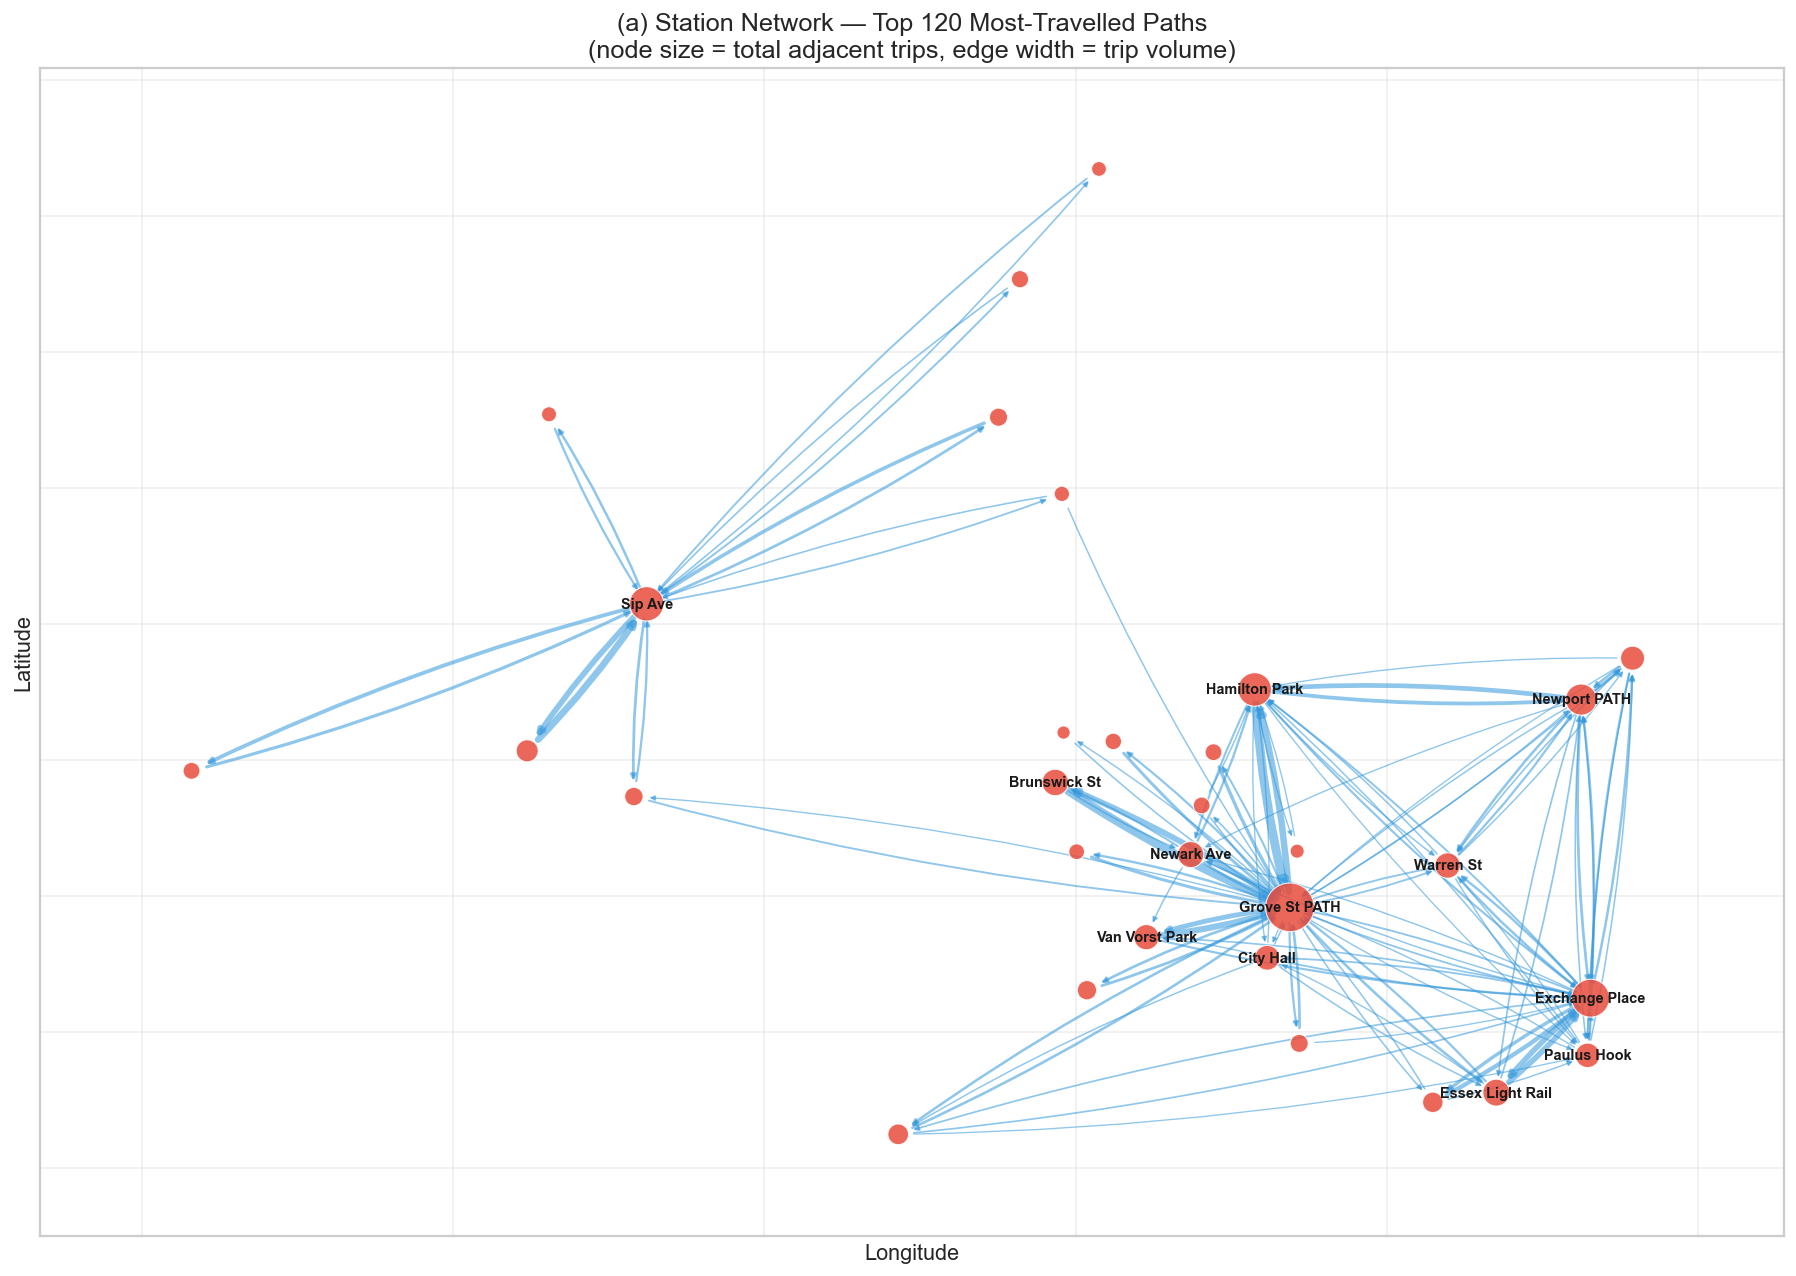

In [9]:
# Aggregate trips per (start, end) pair and keep the top edges
pair_counts = df.groupby(['Start Station Name', 'End Station Name']).size().reset_index(name='Trips')
pair_counts = pair_counts[pair_counts['Start Station Name'] != pair_counts['End Station Name']]
TOP_EDGES = 120
top_edges = pair_counts.nlargest(TOP_EDGES, 'Trips')

# Station coordinates (mean lat/lon)
coords = (df.groupby('Start Station Name')[['Start Station Latitude', 'Start Station Longitude']]
            .mean().rename(columns={'Start Station Latitude':'lat','Start Station Longitude':'lon'}))

# Build directed graph
G = nx.DiGraph()
for _, r in top_edges.iterrows():
    G.add_edge(r['Start Station Name'], r['End Station Name'], weight=r['Trips'])

pos = {n: (coords.loc[n,'lon'], coords.loc[n,'lat']) for n in G.nodes() if n in coords.index}
G = G.subgraph([n for n in G.nodes() if n in pos]).copy()
node_strength = pd.Series({n: pair_counts.query('`Start Station Name`==@n or `End Station Name`==@n')['Trips'].sum() for n in G.nodes()})

fig, ax = plt.subplots(figsize=(14, 10))
weights = np.array([d['weight'] for _,_,d in G.edges(data=True)])
edge_w  = 0.4 + 4.5 * (weights / weights.max())
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_w, edge_color='#3498db', alpha=0.55,
                       arrows=True, arrowsize=6, connectionstyle='arc3,rad=0.05')
node_size = 25 + 700 * (node_strength / node_strength.max())
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size.reindex(G.nodes()).fillna(40).values,
                       node_color='#e74c3c', alpha=0.85, edgecolors='white', linewidths=0.6)
# Label only top 12 hub stations
top_hubs = node_strength.nlargest(12).index
labels   = {n: n[:22] for n in top_hubs if n in pos}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('(a) Station Network — Top 120 Most-Travelled Paths\n(node size = total adjacent trips, edge width = trip volume)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('viz_a_station_network.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (a)

**a) Data Types:**
- Station Name — Nominal (network nodes)
- Station Pair (origin → destination) — Nominal (directed edges)
- Trip Volume per Pair — Quantitative (discrete count)
- Latitude / Longitude — Quantitative (continuous, used for node placement)

**b) Marks and Channels:**
- **Marks:** Nodes (filled circles) + directed edges (curved lines with arrowheads)
- **Channels:** Spatial position (geographic lat/lon), node size (total adjacent trips), edge width (pair trip volume), edge curvature (separates A→B from B→A), colour hue (red nodes vs blue edges for figure–ground separation)

**c) Best Practices Applied:**
- Network restricted to the **top 120 directed edges** to prevent visual clutter (the graph is otherwise hairball-dense)
- Nodes positioned at their **true geographic coordinates** so the diagram doubles as a map
- Curved edges (`arc3,rad=0.05`) so opposite-direction trips between the same two stations do not overlap
- Only the **12 highest-traffic hubs** are labelled, keeping the chart legible
- Edge widths and node sizes are min-clamped so small-volume edges are still visible

**d) Justification:**
A geographic node–link diagram is the canonical representation for a network of places connected by flows. Using lat/lon coordinates instead of an abstract layout (e.g.\ spring) anchors the network in physical space, immediately revealing geographic clusters and corridors. The chart shows a dense Jersey City core with a few long-range edges across the Hudson, and identifies Grove St PATH and Exchange Place as primary hubs.

---
## (b) How do bike trips flow between neighbourhoods or boroughs? Are there prominent inter-neighbourhood routes?

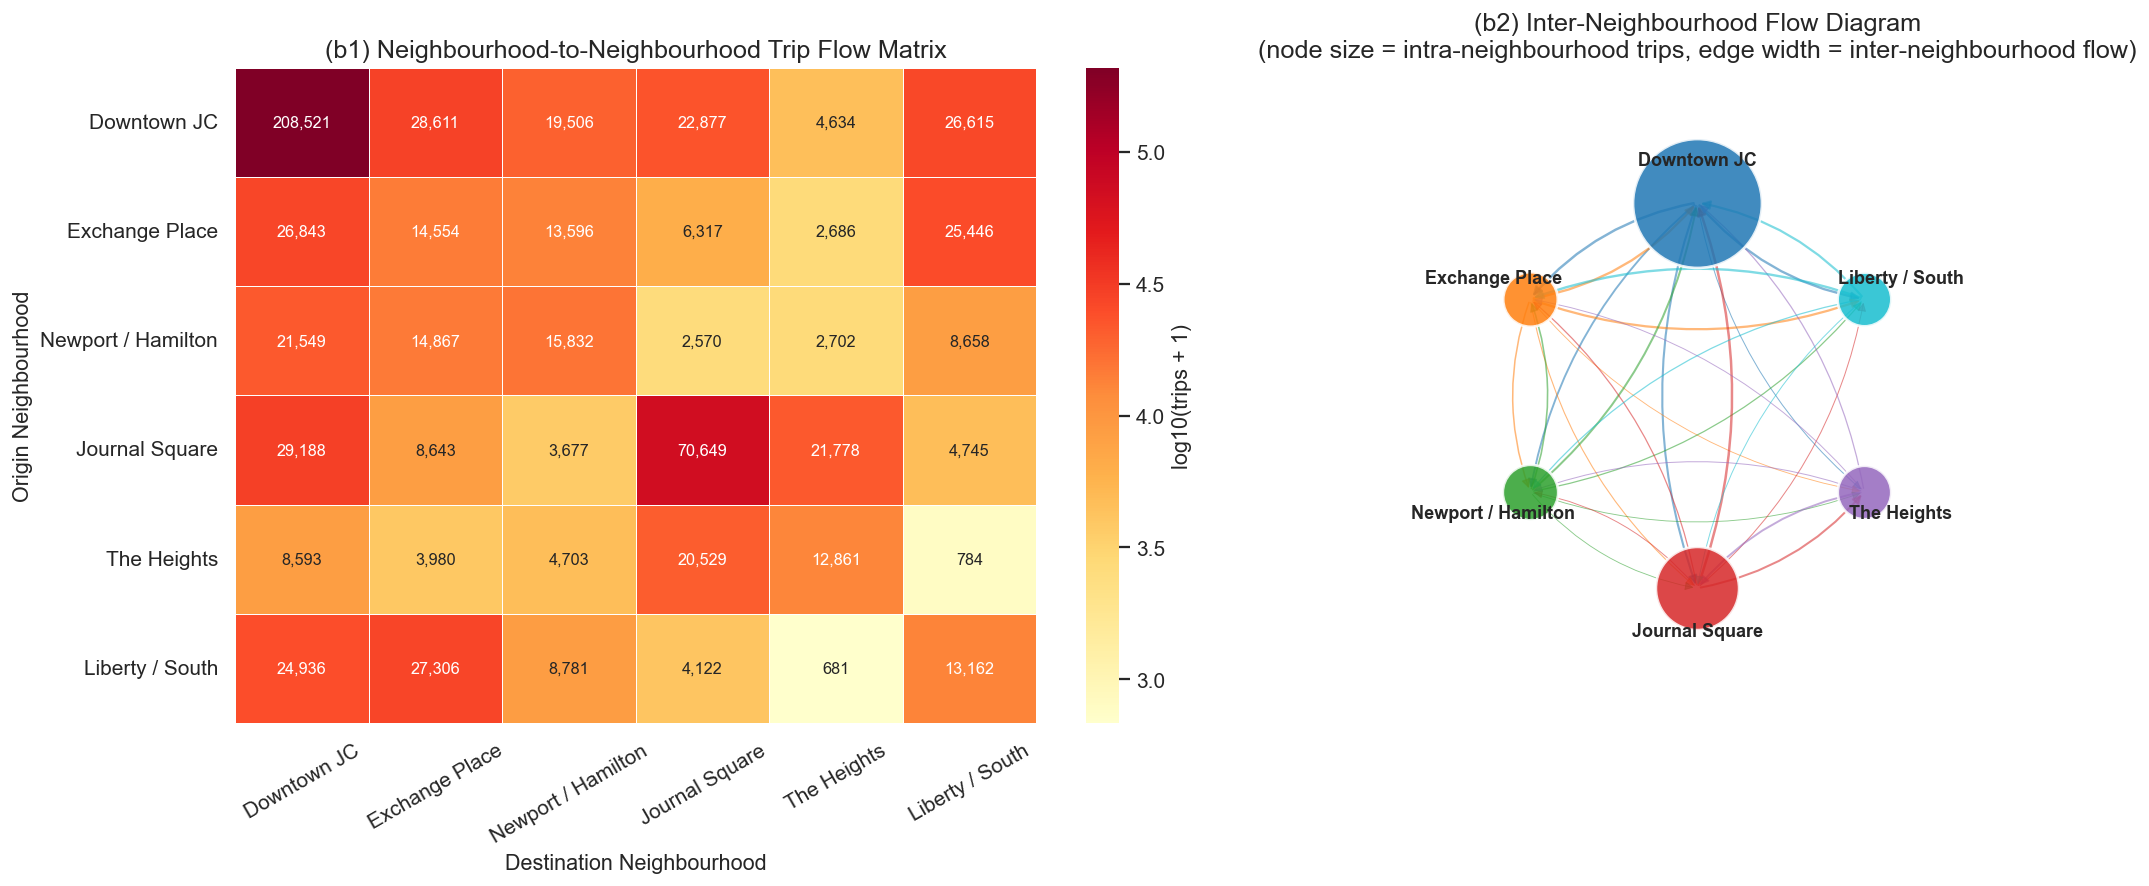

In [10]:
borough_order = [b for b in ['Downtown JC','Exchange Place','Newport / Hamilton','Journal Square','The Heights','Liberty / South','Other']
                 if b in df['Start Borough'].unique() or b in df['End Borough'].unique()]
flow = (df.groupby(['Start Borough','End Borough']).size()
          .unstack(fill_value=0).reindex(index=borough_order, columns=borough_order, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={'width_ratios':[1.05, 1]})

# Left: heatmap (log scale for readability)
log_flow = np.log10(flow + 1)
sns.heatmap(log_flow, annot=flow.values, fmt=',d', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label':'log10(trips + 1)'}, annot_kws={'size':9})
axes[0].set_title('(b1) Neighbourhood-to-Neighbourhood Trip Flow Matrix')
axes[0].set_xlabel('Destination Neighbourhood'); axes[0].set_ylabel('Origin Neighbourhood')
axes[0].tick_params(axis='x', rotation=30); axes[0].tick_params(axis='y', rotation=0)

# Right: chord-like flow diagram (boroughs on a circle, arc widths proportional to flow)
ax = axes[1]
n = len(borough_order)
angles = {b: 2*np.pi*i/n + np.pi/2 for i, b in enumerate(borough_order)}
R = 1.0
node_xy = {b: (R*np.cos(a), R*np.sin(a)) for b, a in angles.items()}
max_flow = flow.values.max()
for o in borough_order:
    for d in borough_order:
        if o == d: continue
        v = flow.loc[o, d]
        if v < max_flow * 0.005: continue
        x1, y1 = node_xy[o]; x2, y2 = node_xy[d]
        lw = 0.4 + 7 * (v / max_flow)
        ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2), arrowstyle='-|>',
                                     mutation_scale=10, lw=lw,
                                     color=BOROUGH_COLORS.get(o,'#888'), alpha=0.55,
                                     connectionstyle='arc3,rad=0.18'))
for b,(x,y) in node_xy.items():
    self_loop = flow.loc[b,b]
    size = 600 + 4500 * (self_loop / max_flow)
    ax.scatter(x, y, s=size, color=BOROUGH_COLORS.get(b,'#888'), alpha=0.85,
               edgecolors='white', linewidths=1.5, zorder=3)
    ax.text(x*1.22, y*1.22, b, ha='center', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(-1.7,1.7); ax.set_ylim(-1.7,1.7); ax.set_aspect('equal'); ax.axis('off')
ax.set_title('(b2) Inter-Neighbourhood Flow Diagram\n(node size = intra-neighbourhood trips, edge width = inter-neighbourhood flow)')
plt.tight_layout(); plt.savefig('viz_b_borough_flow.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (b)

**a) Data Types:**
- Origin Borough, Destination Borough — Nominal
- Trip Count — Quantitative (discrete)

**b) Marks and Channels:**
- *Heatmap*: rectangular cell marks; channels = colour saturation (log trip count) + numeric annotation
- *Chord/flow diagram*: node marks (filled circles for boroughs) + curved directed edges; channels = node size (intra-neighbourhood trips), edge width (inter-neighbourhood flow), edge colour (origin), curvature (separates outbound/inbound)

**c) Best Practices Applied:**
- Two complementary views side-by-side — the matrix gives **exact counts**, the chord view gives **shape and direction**
- **Log-scaled** colour for the matrix because intra-neighbourhood flow dwarfs inter-neighbourhood flow
- Edges below 0.5 % of the max are dropped so faint noise does not obscure dominant routes
- Self-loops are encoded as **node size** rather than as edges, avoiding a self-arrow tangle
- Consistent neighbourhood colour palette is reused throughout the report

**d) Justification:**
A pure node–link map would be too sparse for only a handful of regions; the matrix + chord pairing is standard for showing *origin–destination flow* between a small set of categories. It reveals dense intra-neighbourhood trips in the Downtown JC core and pronounced bidirectional flows between Downtown JC and Exchange Place — the two PATH-station clusters — while peripheral neighbourhoods (The Heights, Liberty / South) act mostly as origins/destinations rather than through-routes.

---
## (c) What are the most common round-trip and near round-trip patterns (start and end stations geographically close)?

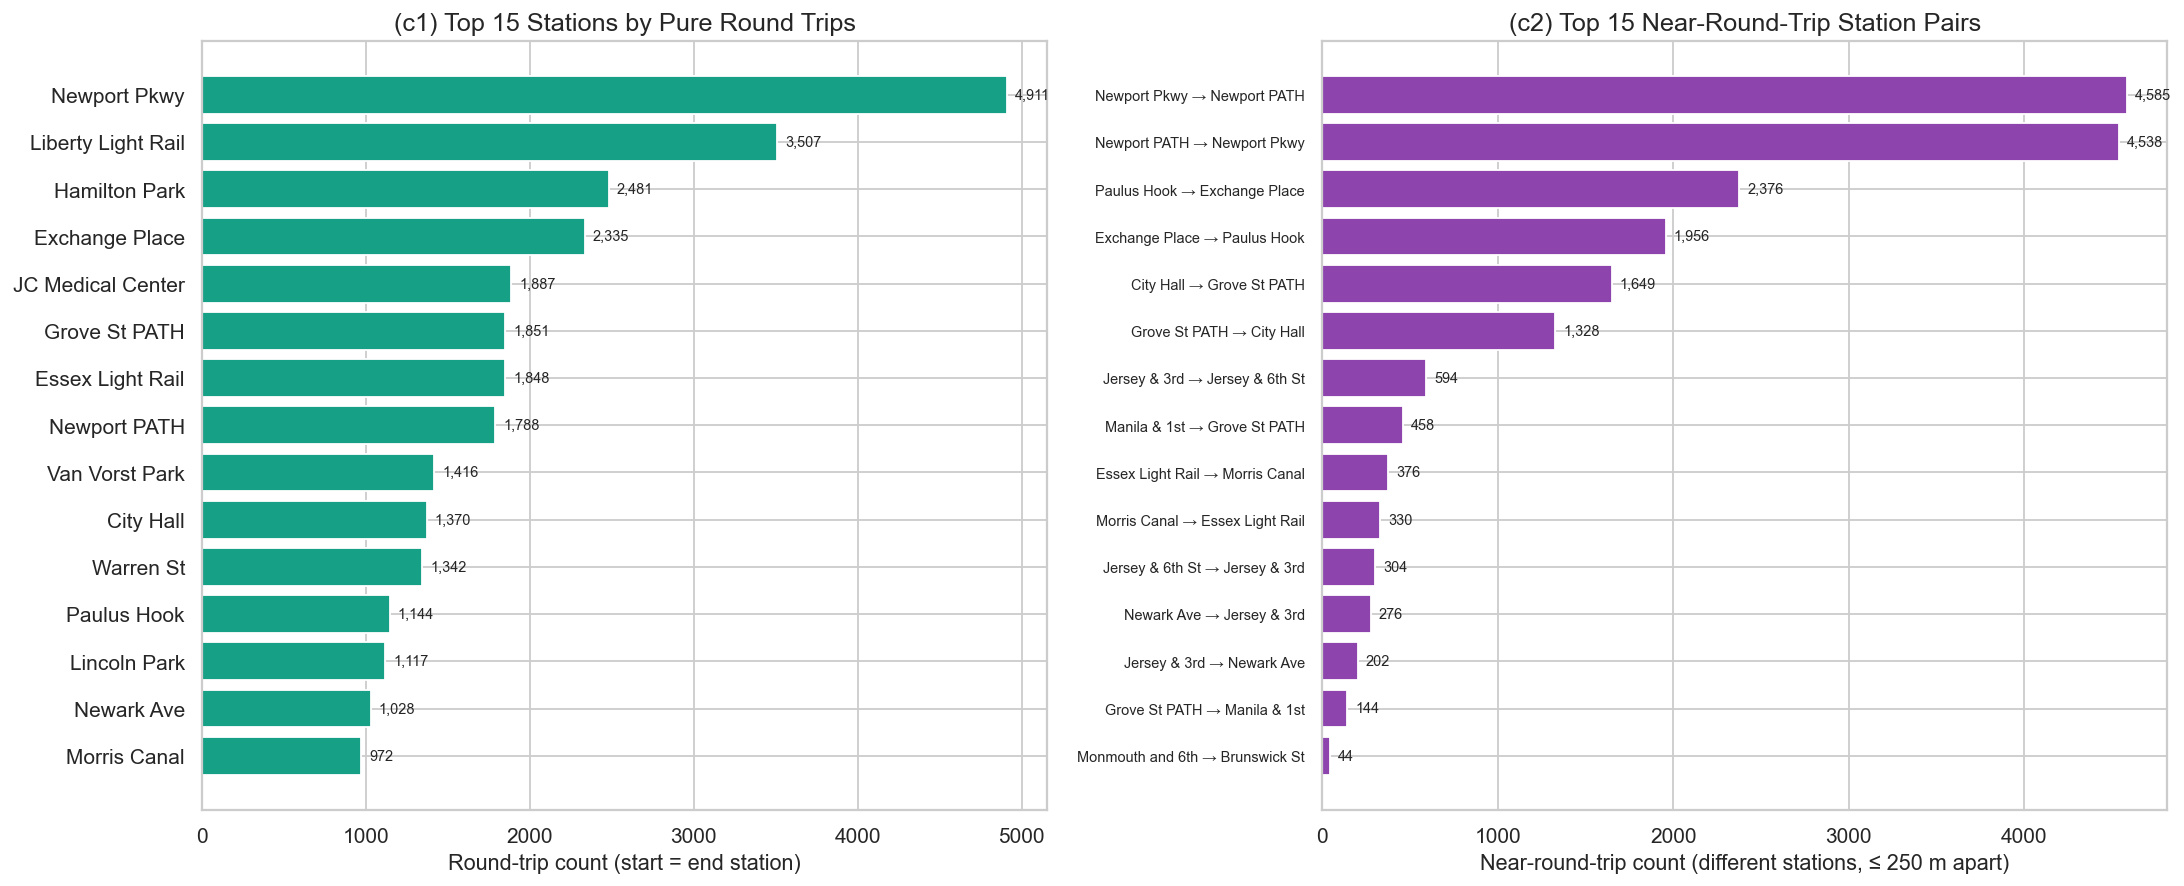

Pure round trips:          38,075  (5.18 %)
Near round trips (≤250m):   19,312  (2.63 %)


In [11]:
# Round-trip = same start and end station; near round-trip = different stations within 250 m
df['IsRoundTrip']     = df['Start Station Name'] == df['End Station Name']
df['IsNearRoundTrip'] = (~df['IsRoundTrip']) & (df['Trip_Distance_km'] <= 0.25)

round_by_station = (df[df['IsRoundTrip']].groupby('Start Station Name').size()
                      .nlargest(15).rename('RoundTrips'))
near_pairs = (df[df['IsNearRoundTrip']]
                .groupby(['Start Station Name','End Station Name']).size()
                .nlargest(15).rename('NearRoundTrips').reset_index())
near_pairs['Pair'] = near_pairs['Start Station Name'].str[:18] + ' → ' + near_pairs['End Station Name'].str[:18]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
axes[0].barh(round_by_station.index[::-1], round_by_station.values[::-1], color='#16a085')
axes[0].set_xlabel('Round-trip count (start = end station)')
axes[0].set_title('(c1) Top 15 Stations by Pure Round Trips')
for i, v in enumerate(round_by_station.values[::-1]):
    axes[0].text(v + max(round_by_station.values)*0.01, i, f'{v:,}', va='center', fontsize=8)

axes[1].barh(near_pairs['Pair'][::-1], near_pairs['NearRoundTrips'][::-1], color='#8e44ad')
axes[1].set_xlabel('Near-round-trip count (different stations, ≤ 250 m apart)')
axes[1].set_title('(c2) Top 15 Near-Round-Trip Station Pairs')
for i, v in enumerate(near_pairs['NearRoundTrips'].values[::-1]):
    axes[1].text(v + max(near_pairs['NearRoundTrips'])*0.01, i, f'{v:,}', va='center', fontsize=8)
axes[1].tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.savefig('viz_c_round_trips.png', dpi=200, bbox_inches='tight'); plt.show()

print(f"Pure round trips:        {df['IsRoundTrip'].sum():>8,}  ({df['IsRoundTrip'].mean()*100:.2f} %)")
print(f"Near round trips (≤250m): {df['IsNearRoundTrip'].sum():>8,}  ({df['IsNearRoundTrip'].mean()*100:.2f} %)")

### Task 2 — Analysis for (c)

**a) Data Types:**
- Station / Station-Pair — Nominal
- Round-trip count — Quantitative (discrete)
- Trip distance — Quantitative (continuous, used as 250 m threshold)

**b) Marks and Channels:**
- **Marks:** Horizontal rectangular bars
- **Channels:** Bar length (count), y-position (station/pair, ranked), colour hue (teal vs purple to distinguish the two panels)

**c) Best Practices Applied:**
- Two side-by-side panels separating *pure* round trips (start = end) from *near* round trips (different stations within 250 m), since these are conceptually distinct
- Comma-formatted value labels at bar ends for precise reading
- Pairs truncated to 18 characters per side to fit the axis without rotation
- Bars sorted ascending so the longest sits on top

**d) Justification:**
Ranked horizontal bar charts are optimal for top-N nominal lists. Splitting into two panels is essential because aggregating both into one bar would conflate two different behaviours: leisure loops (return-to-origin) versus very short transit/parking-shift trips. Park-adjacent stations (Liberty Light Rail, Lincoln Park) dominate pure round trips, confirming leisure use, while near-round-trip pairs are cluster-redocking events at PATH stations.

---
## (d) What is the frequency of trips between specific pairs of stations? Can we detect station pairs with bidirectional high traffic?

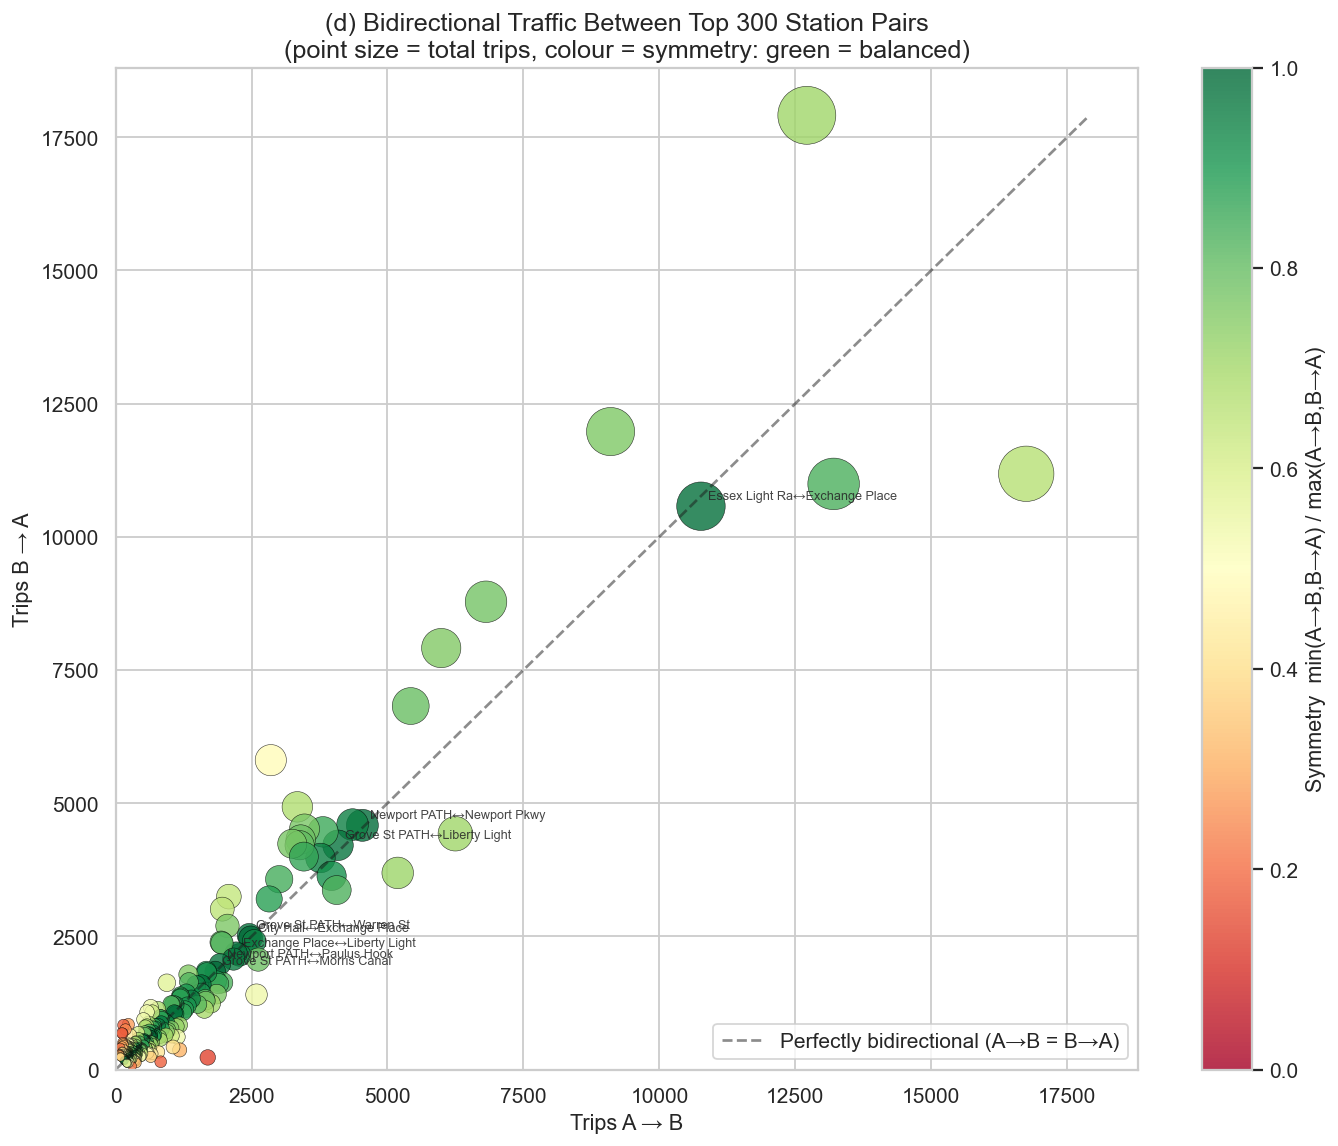

In [12]:
# Build undirected pair key, then compute A→B and B→A counts
df_dir = df[df['Start Station Name'] != df['End Station Name']].copy()
df_dir['A'] = np.where(df_dir['Start Station Name'] < df_dir['End Station Name'],
                       df_dir['Start Station Name'], df_dir['End Station Name'])
df_dir['B'] = np.where(df_dir['Start Station Name'] < df_dir['End Station Name'],
                       df_dir['End Station Name'],   df_dir['Start Station Name'])
df_dir['ABorder'] = df_dir['Start Station Name'] == df_dir['A']
pair_dir = (df_dir.groupby(['A','B','ABorder']).size().unstack(fill_value=0)
             .rename(columns={True:'A_to_B', False:'B_to_A'}).reset_index())
pair_dir['Total'] = pair_dir['A_to_B'] + pair_dir['B_to_A']
pair_dir['Symmetry'] = (pair_dir[['A_to_B','B_to_A']].min(axis=1)
                        / pair_dir[['A_to_B','B_to_A']].max(axis=1).replace(0, np.nan))
top_pairs = pair_dir.nlargest(300, 'Total')

fig, ax = plt.subplots(figsize=(11, 9))
sc = ax.scatter(top_pairs['A_to_B'], top_pairs['B_to_A'],
                s=10 + top_pairs['Total']/30, c=top_pairs['Symmetry'],
                cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidths=0.3, vmin=0, vmax=1)
lim = max(top_pairs['A_to_B'].max(), top_pairs['B_to_A'].max())
ax.plot([0,lim],[0,lim], 'k--', alpha=0.5, label='Perfectly bidirectional (A→B = B→A)')
# Annotate the 8 most bidirectional high-volume pairs
high_sym = top_pairs[top_pairs['Total'] > top_pairs['Total'].quantile(0.85)].nlargest(8, 'Symmetry')
for _, r in high_sym.iterrows():
    ax.annotate(f"{r['A'][:14]}↔{r['B'][:14]}", (r['A_to_B'], r['B_to_A']),
                fontsize=7, alpha=0.85, xytext=(4,4), textcoords='offset points')
ax.set_xlabel('Trips A → B'); ax.set_ylabel('Trips B → A')
ax.set_title('(d) Bidirectional Traffic Between Top 300 Station Pairs\n(point size = total trips, colour = symmetry: green = balanced)')
ax.legend(loc='lower right'); ax.set_xlim(0, lim*1.05); ax.set_ylim(0, lim*1.05)
plt.colorbar(sc, ax=ax, label='Symmetry  min(A→B,B→A) / max(A→B,B→A)')
plt.tight_layout(); plt.savefig('viz_d_bidirectional_pairs.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (d)

**a) Data Types:**
- Station Pair — Nominal
- Trips A→B, Trips B→A, Total Trips — Quantitative (discrete counts)
- Symmetry index (min/max of the two directions) — Quantitative (continuous, 0–1)

**b) Marks and Channels:**
- **Marks:** Points (scatter) plus a reference line
- **Channels:** x-position (A→B count), y-position (B→A count), point area (total volume), point colour (symmetry, RdYlGn diverging map)

**c) Best Practices Applied:**
- A **45° reference line** is added so the eye can immediately compare each point's distance from perfect symmetry
- Two visual variables (size + colour) encode independent quantities (volume and symmetry) without redundancy
- Restricted to the **top 300 pairs by total volume** so individual points remain distinguishable
- Only the most bidirectional high-volume pairs are labelled to avoid annotation overlap
- Symmetric x/y limits and a square aspect ratio so the diagonal appears at exactly 45°

**d) Justification:**
A scatter-with-diagonal is the canonical visualization for two paired quantitative measurements where equality is the question of interest. Mapping symmetry to colour gives a third dimension without cluttering the layout. The chart shows that most high-volume corridors lie tightly along the diagonal — i.e.\ they are highly bidirectional commuter routes — while a few outliers (e.g.\ ferry-terminal feeders) carry mostly one-way flow.

---
## (e) How are trips distributed across boroughs and stations within boroughs based on the total number of trips?

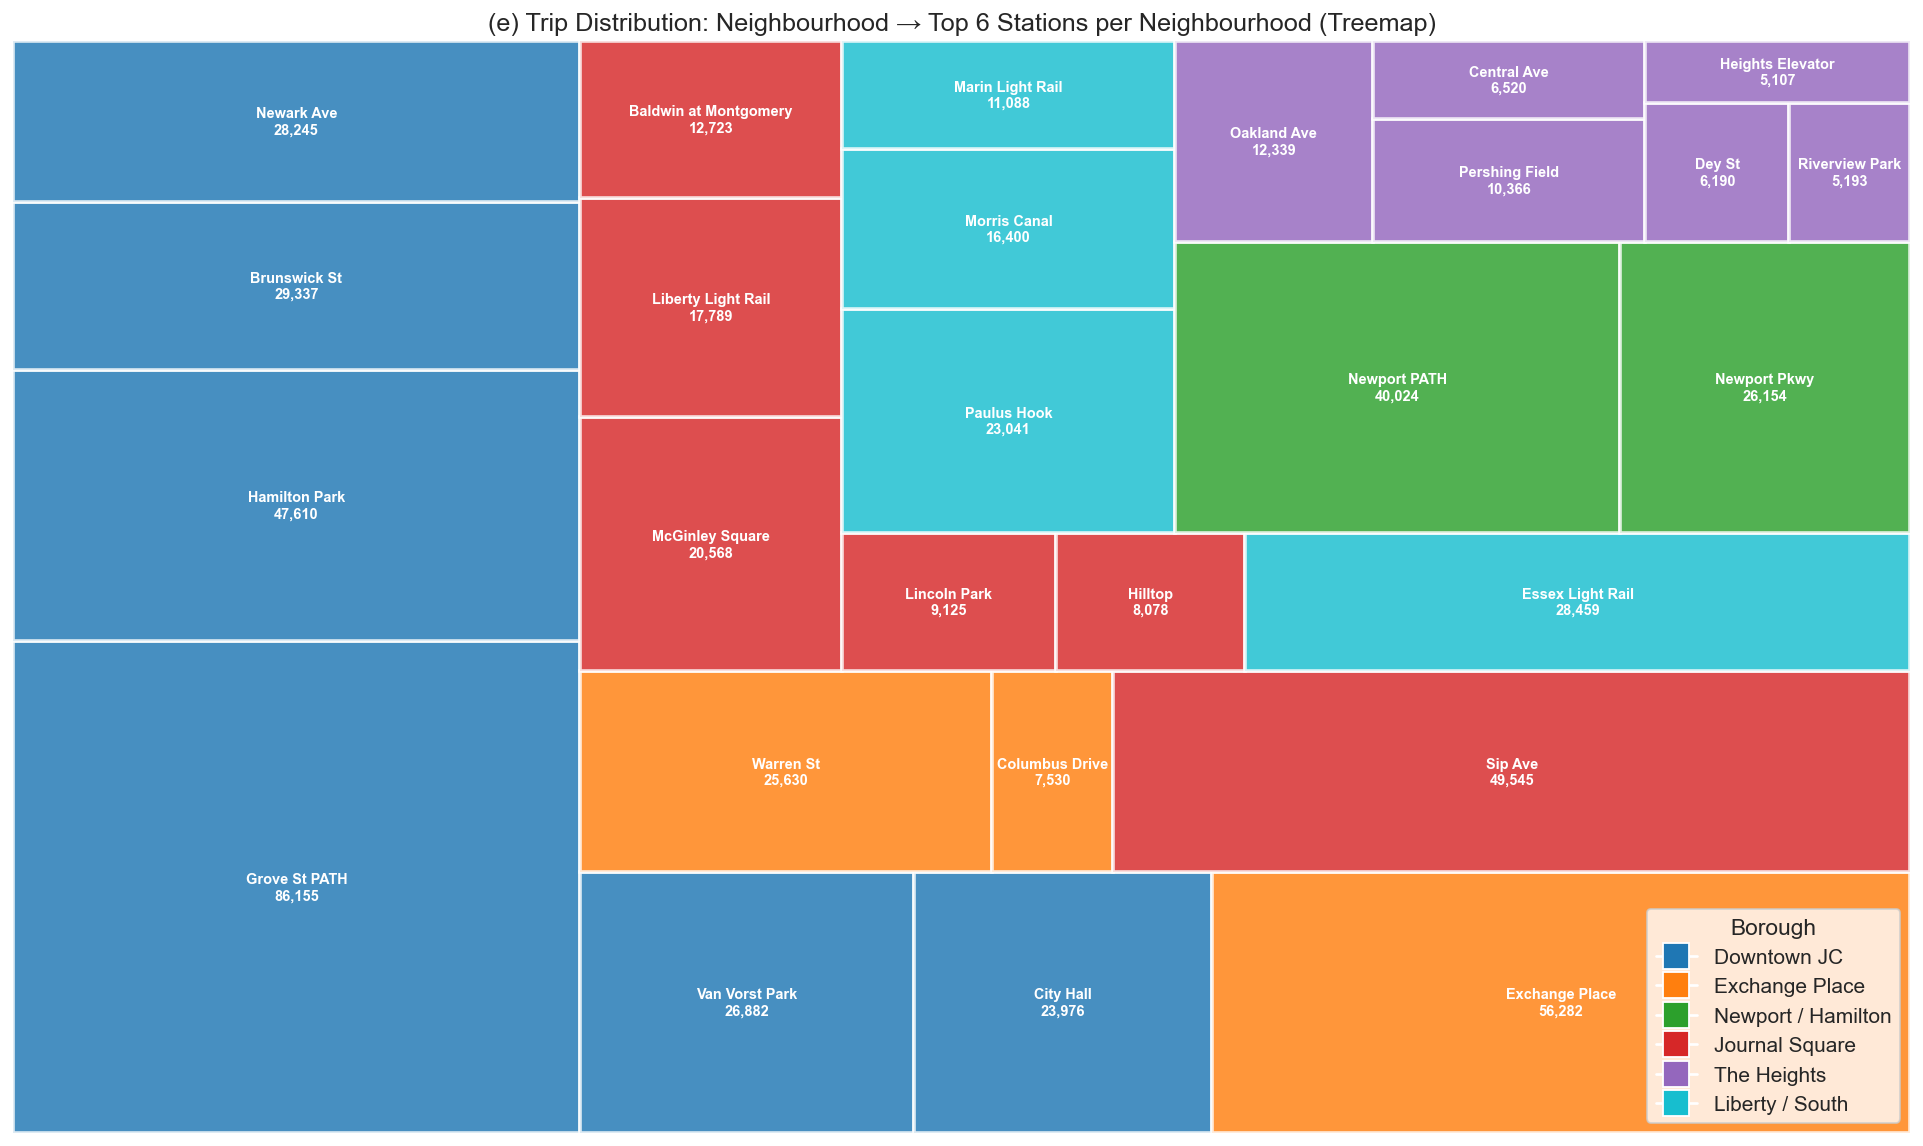

In [13]:
# Hierarchical: Neighbourhood → top 6 stations within neighbourhood
stat = (df.groupby(['Start Borough','Start Station Name']).size()
          .reset_index(name='Trips'))
blocks = []
for b in stat['Start Borough'].unique():
    sub = stat[stat['Start Borough']==b].nlargest(6, 'Trips')
    blocks.append(sub)
blocks = pd.concat(blocks).sort_values(['Start Borough','Trips'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(15, 9))
sizes  = blocks['Trips'].values
labels = [f"{r['Start Station Name'][:22]}\n{r['Trips']:,}" for _, r in blocks.iterrows()]
colors = [BOROUGH_COLORS.get(b, '#888') for b in blocks['Start Borough']]
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.82, ax=ax,
              text_kwargs={'fontsize':8, 'color':'white', 'weight':'bold'},
              edgecolor='white', linewidth=2)
ax.axis('off')
ax.set_title('(e) Trip Distribution: Neighbourhood → Top 6 Stations per Neighbourhood (Treemap)')
legend_h = [Line2D([0],[0], marker='s', color='w', markerfacecolor=c, markersize=14, label=b)
            for b,c in BOROUGH_COLORS.items() if b in blocks['Start Borough'].unique()]
ax.legend(handles=legend_h, loc='lower right', frameon=True, title='Borough')
plt.tight_layout(); plt.savefig('viz_e_borough_station_treemap.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (e)

**a) Data Types:**
- Borough — Nominal (top-level grouping)
- Station Name — Nominal (within-neighbourhood children)
- Trip Count — Quantitative (discrete)

**b) Marks and Channels:**
- **Marks:** Nested rectangles (treemap tiles)
- **Channels:** Tile area (trip count), tile colour hue (neighbourhood), white border (separator)

**c) Best Practices Applied:**
- Limit to **top 6 stations per neighbourhood** so individual tiles remain readable
- Each tile annotated with the station name (truncated) and exact trip count
- Borough colour palette is consistent with all other charts
- White separators and bold white labels guarantee contrast against any neighbourhood colour
- Legend included even though colour is also implicit in groupings

**d) Justification:**
A treemap is purpose-built for *part-to-whole* visualizations with two levels of hierarchy. It exploits area as the primary channel — the most accurate non-position channel for ratio judgements at small differences — while colour preserves the parent grouping. The chart instantly shows Jersey City as the dominant neighbourhood and reveals that within Jersey City a handful of PATH-adjacent stations carry the bulk of trips.

---
## (f) How is trip volume distributed across boroughs, user types, and genders?

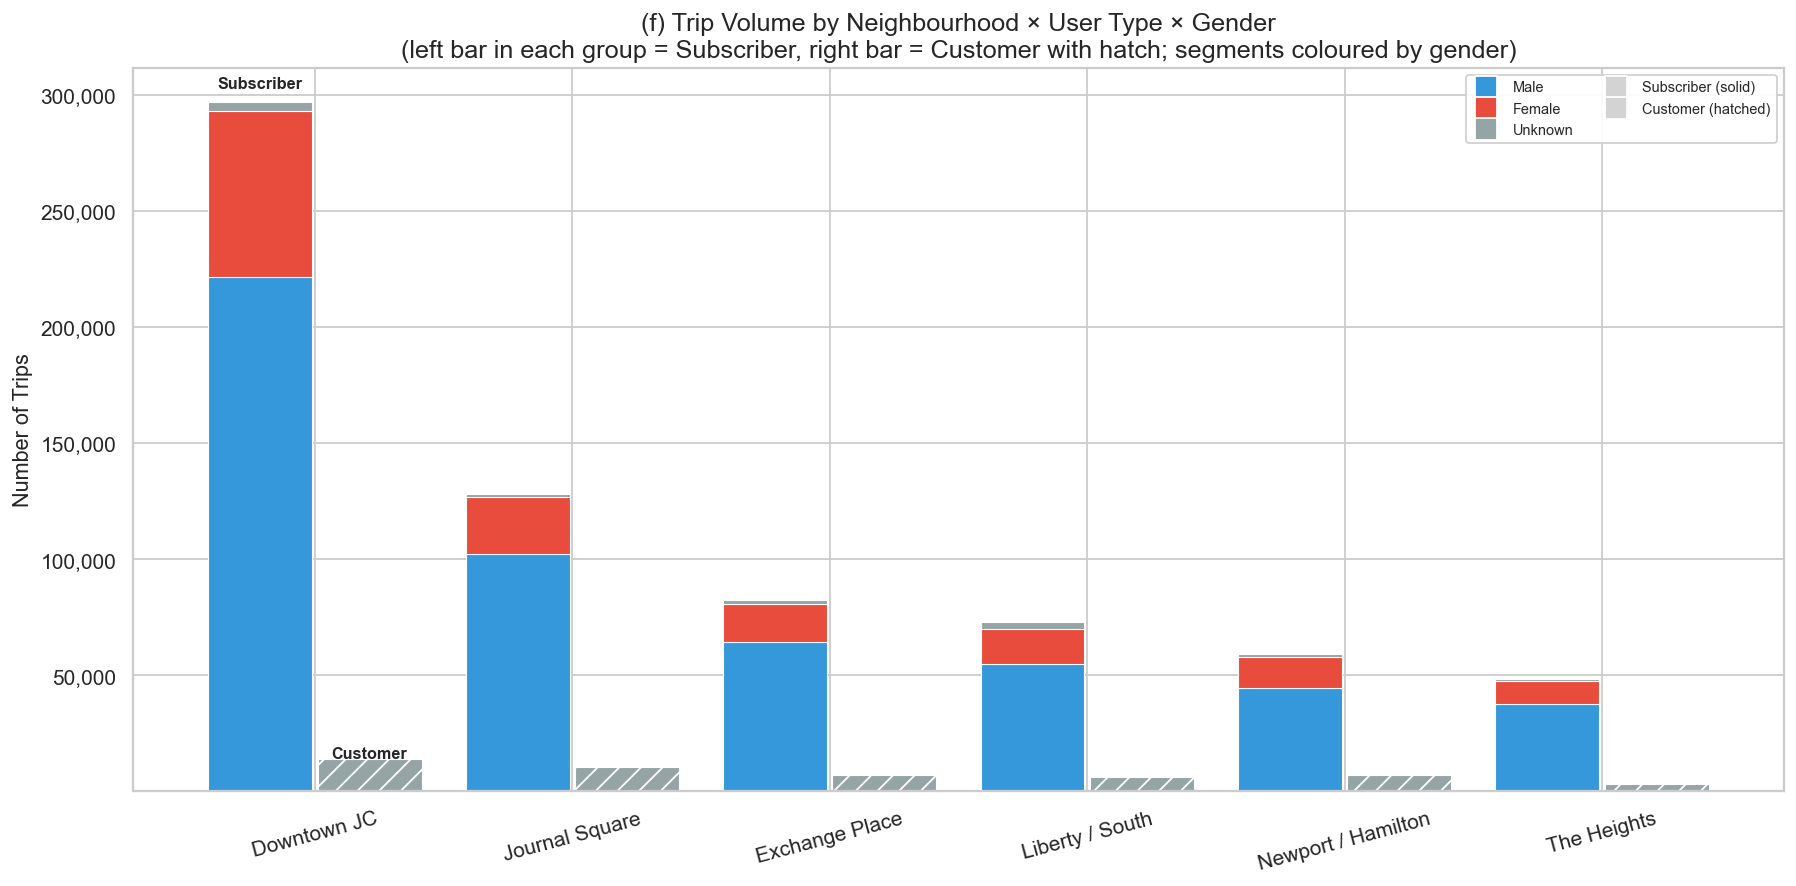

In [14]:
g = (df.groupby(['Start Borough','User Type','Gender_Label']).size().reset_index(name='Trips'))
boroughs_ordered = (g.groupby('Start Borough')['Trips'].sum().sort_values(ascending=False).index.tolist())
user_types  = ['Subscriber','Customer']
gender_list = ['Male','Female','Unknown']

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(boroughs_ordered))
group_w, bar_w = 0.85, 0.85/2
for i, ut in enumerate(user_types):
    bottom = np.zeros(len(boroughs_ordered))
    for gen in gender_list:
        vals = []
        for b in boroughs_ordered:
            v = g[(g['Start Borough']==b)&(g['User Type']==ut)&(g['Gender_Label']==gen)]['Trips'].sum()
            vals.append(v)
        ax.bar(x + (i-0.5)*bar_w, vals, bar_w*0.95, bottom=bottom,
               color=GENDER_COLORS[gen], edgecolor='white', linewidth=0.6,
               label=f'{ut} – {gen}' if i == 0 else None,
               hatch='' if ut=='Subscriber' else '//')
        bottom += np.array(vals)
    ax.text(x[0] + (i-0.5)*bar_w, bottom[0]*1.02, ut, ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(boroughs_ordered, rotation=15)
ax.set_ylabel('Number of Trips')
ax.set_title('(f) Trip Volume by Neighbourhood × User Type × Gender\n(left bar in each group = Subscriber, right bar = Customer with hatch; segments coloured by gender)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
legend_h = [Line2D([0],[0], marker='s', color='w', markerfacecolor=c, markersize=12, label=g_) for g_,c in GENDER_COLORS.items()]
legend_h += [Line2D([0],[0], marker='s', color='w', markerfacecolor='lightgrey', markersize=12, label='Subscriber (solid)'),
             Line2D([0],[0], marker='s', color='w', markerfacecolor='lightgrey', markersize=12, label='Customer (hatched)')]
ax.legend(handles=legend_h, loc='upper right', ncol=2, fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.savefig('viz_f_borough_user_gender.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (f)

**a) Data Types:**
- Borough, User Type, Gender — all Nominal
- Trip Count — Quantitative (discrete)

**b) Marks and Channels:**
- **Marks:** Stacked vertical bars in groups of two (Subscriber, Customer)
- **Channels:** Bar height (trip count), stack-segment colour (gender), texture/hatch (user type), x-position (neighbourhood)

**c) Best Practices Applied:**
- Three categorical dimensions are encoded with three distinct visual channels (position, hatch, colour) so no information is lost
- Boroughs are sorted by total trips descending — easier to compare
- Y-axis uses thousands-separator formatting for large counts
- Composite legend shows both the colour scheme (gender) and the hatch scheme (user type)
- Subscriber and Customer bars share the same x-tick to keep grouping obvious

**d) Justification:**
When three categorical breakdowns must be visualised together, a stacked-grouped bar is the most compact and least cluttered alternative to a Sankey or matrix grid. It preserves direct height comparison across boroughs while still exposing the gender mix within each user-type bar. Jersey City Subscribers are the dominant cohort, with Male again representing ~70 % of all groups.

---
## (g) How do bike usage patterns break down by time of day → user type → gender?

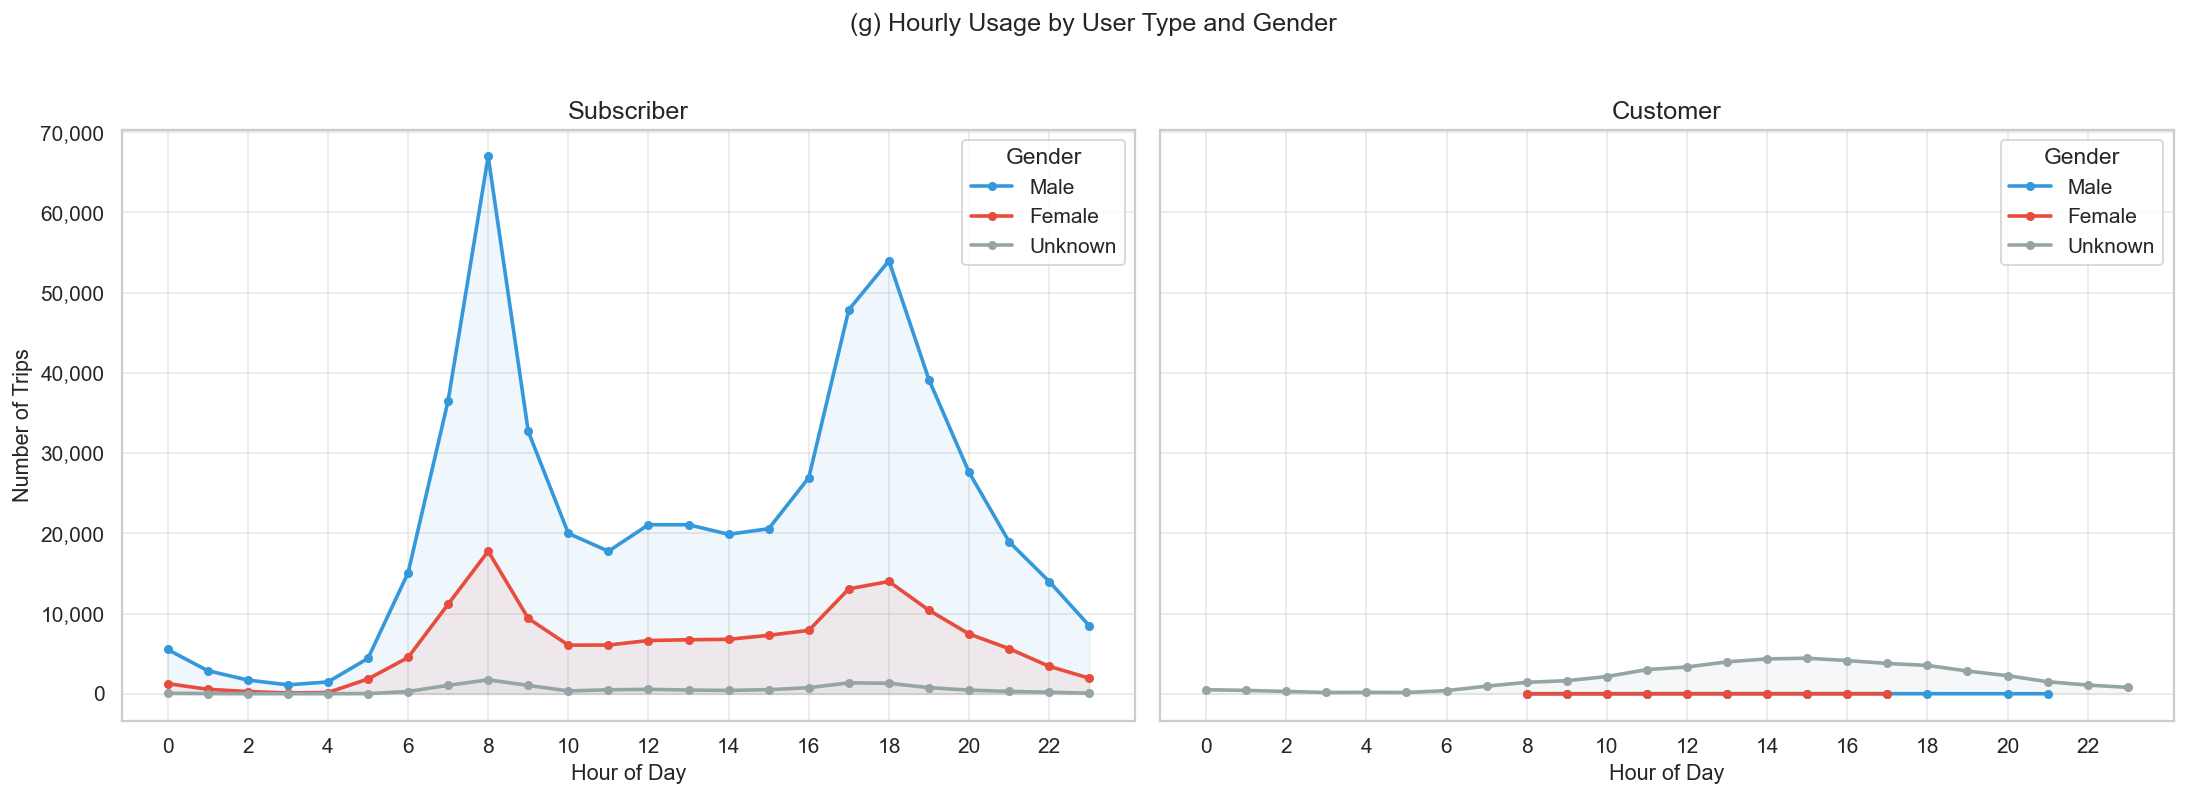

In [15]:
h = df.groupby(['Hour','User Type','Gender_Label']).size().reset_index(name='Trips')
fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)
for ax, ut in zip(axes, ['Subscriber','Customer']):
    for gen in ['Male','Female','Unknown']:
        sub = h[(h['User Type']==ut)&(h['Gender_Label']==gen)].sort_values('Hour')
        ax.plot(sub['Hour'], sub['Trips'], marker='o', markersize=4,
                color=GENDER_COLORS[gen], label=gen, linewidth=2)
        ax.fill_between(sub['Hour'], sub['Trips'], alpha=0.08, color=GENDER_COLORS[gen])
    ax.set_title(f'{ut}'); ax.set_xlabel('Hour of Day')
    ax.set_xticks(range(0,24,2)); ax.legend(title='Gender'); ax.grid(True, alpha=0.4)
axes[0].set_ylabel('Number of Trips')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
fig.suptitle('(g) Hourly Usage by User Type and Gender', fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig('viz_g_time_user_gender.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (g)

**a) Data Types:**
- Hour of Day — Ordinal (0–23)
- User Type — Nominal (Subscriber, Customer)
- Gender — Nominal (Male, Female, Unknown)
- Trip Count — Quantitative (discrete)

**b) Marks and Channels:**
- **Marks:** Points connected by lines, with a faint area fill
- **Channels:** x-position (hour), y-position (trip count), colour hue (gender), facet/panel position (user type), area fill (visual emphasis)

**c) Best Practices Applied:**
- **Faceting by user type** isolates the two very different temporal signatures (commuter vs leisure) without clutter
- **Shared y-axis** for honest cross-panel comparison of magnitudes
- Light alpha fill (0.08) under each line aids tracking without occluding overlaps
- Gender colour scheme is consistent with charts (b), (f), (k)
- Hour ticks every 2 h to balance density and label readability

**d) Justification:**
Faceted line charts are the strongest design when one ordinal axis (hour) interacts with two categorical breakdowns. The Subscriber panel shows two sharp rush-hour peaks, while the Customer panel displays a single broad midday peak — instantly revealing commuter vs tourist behaviour. Within each panel, gender separation is preserved by colour.

---
## (h) Which boroughs have the highest average trip durations or trip volumes?

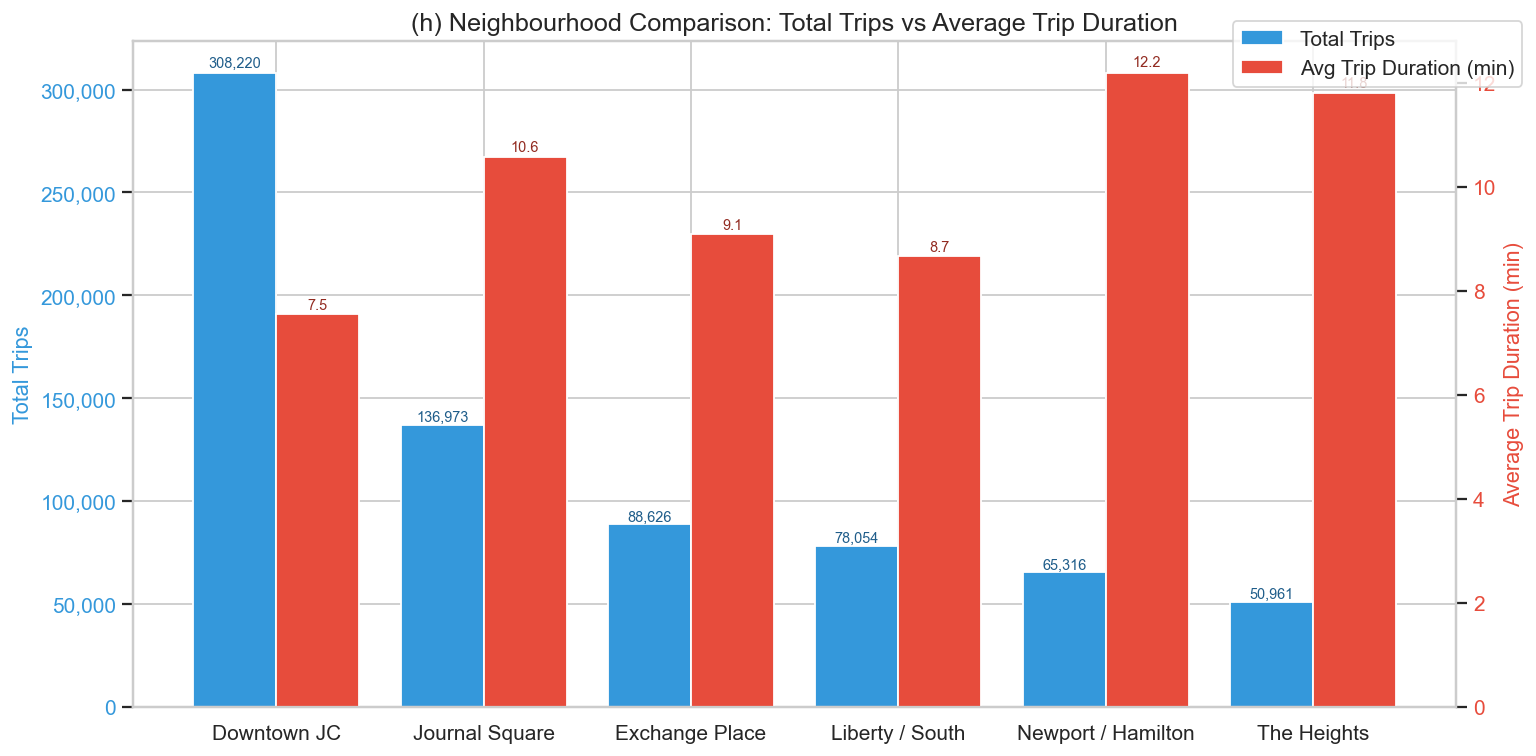

In [16]:
# Cap durations at 99th percentile for a fair mean
cap = df['Trip_Duration_min'].quantile(0.99)
df_cap = df[df['Trip_Duration_min'] <= cap]
borough_stats = (df_cap.groupby('Start Borough')
                   .agg(Trips=('Trip Duration','count'),
                        AvgDuration=('Trip_Duration_min','mean'))
                   .reset_index().sort_values('Trips', ascending=False))
borough_stats = borough_stats[borough_stats['Start Borough'] != 'Other']

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(borough_stats)); w = 0.4
b1 = ax1.bar(x - w/2, borough_stats['Trips'], w, color='#3498db',
             label='Total Trips', edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(borough_stats['Start Borough'])
ax1.set_ylabel('Total Trips', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax2 = ax1.twinx()
b2 = ax2.bar(x + w/2, borough_stats['AvgDuration'], w, color='#e74c3c',
             label='Avg Trip Duration (min)', edgecolor='white')
ax2.set_ylabel('Average Trip Duration (min)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c'); ax2.grid(False)
for bar in b1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.005,
             f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=8, color='#1f5d8a')
for bar in b2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.005,
             f"{bar.get_height():.1f}", ha='center', va='bottom', fontsize=8, color='#922b21')
ax1.set_title('(h) Neighbourhood Comparison: Total Trips vs Average Trip Duration')
fig.legend(loc='upper right', bbox_to_anchor=(0.99, 0.97))
plt.tight_layout(); plt.savefig('viz_h_borough_volume_duration.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (h)

**a) Data Types:**
- Borough — Nominal
- Total Trips, Average Trip Duration — Quantitative (discrete count and continuous minutes)

**b) Marks and Channels:**
- **Marks:** Two side-by-side rectangular bars per neighbourhood
- **Channels:** Bar height (one per metric), colour hue (blue = volume, red = avg duration), dual y-axes (independent scales)

**c) Best Practices Applied:**
- **Twin y-axes** are colour-matched to their respective bars so the reader instantly knows which axis to read
- 99 ᵗʰ-percentile cap on durations so a few extreme trips do not distort the mean
- Numeric value labels on every bar — no axis squinting required
- 'Other' neighbourhood excluded since it represents only mis-classified or ferry-area stations
- Boroughs sorted by trip volume descending

**d) Justification:**
When two metrics with different units must be compared across the same nominal axis, a dual-axis grouped bar chart is the most space-efficient option (and far clearer than a connected scatter for only 2–4 categories). The chart shows that Downtown JC dominates trip volume, but **Liberty / South** and **The Heights** show the longest average durations — consistent with leisure rides near Liberty State Park and longer commutes from the residential hill area.

---
## (i) Where are the busiest start and end stations geographically located?

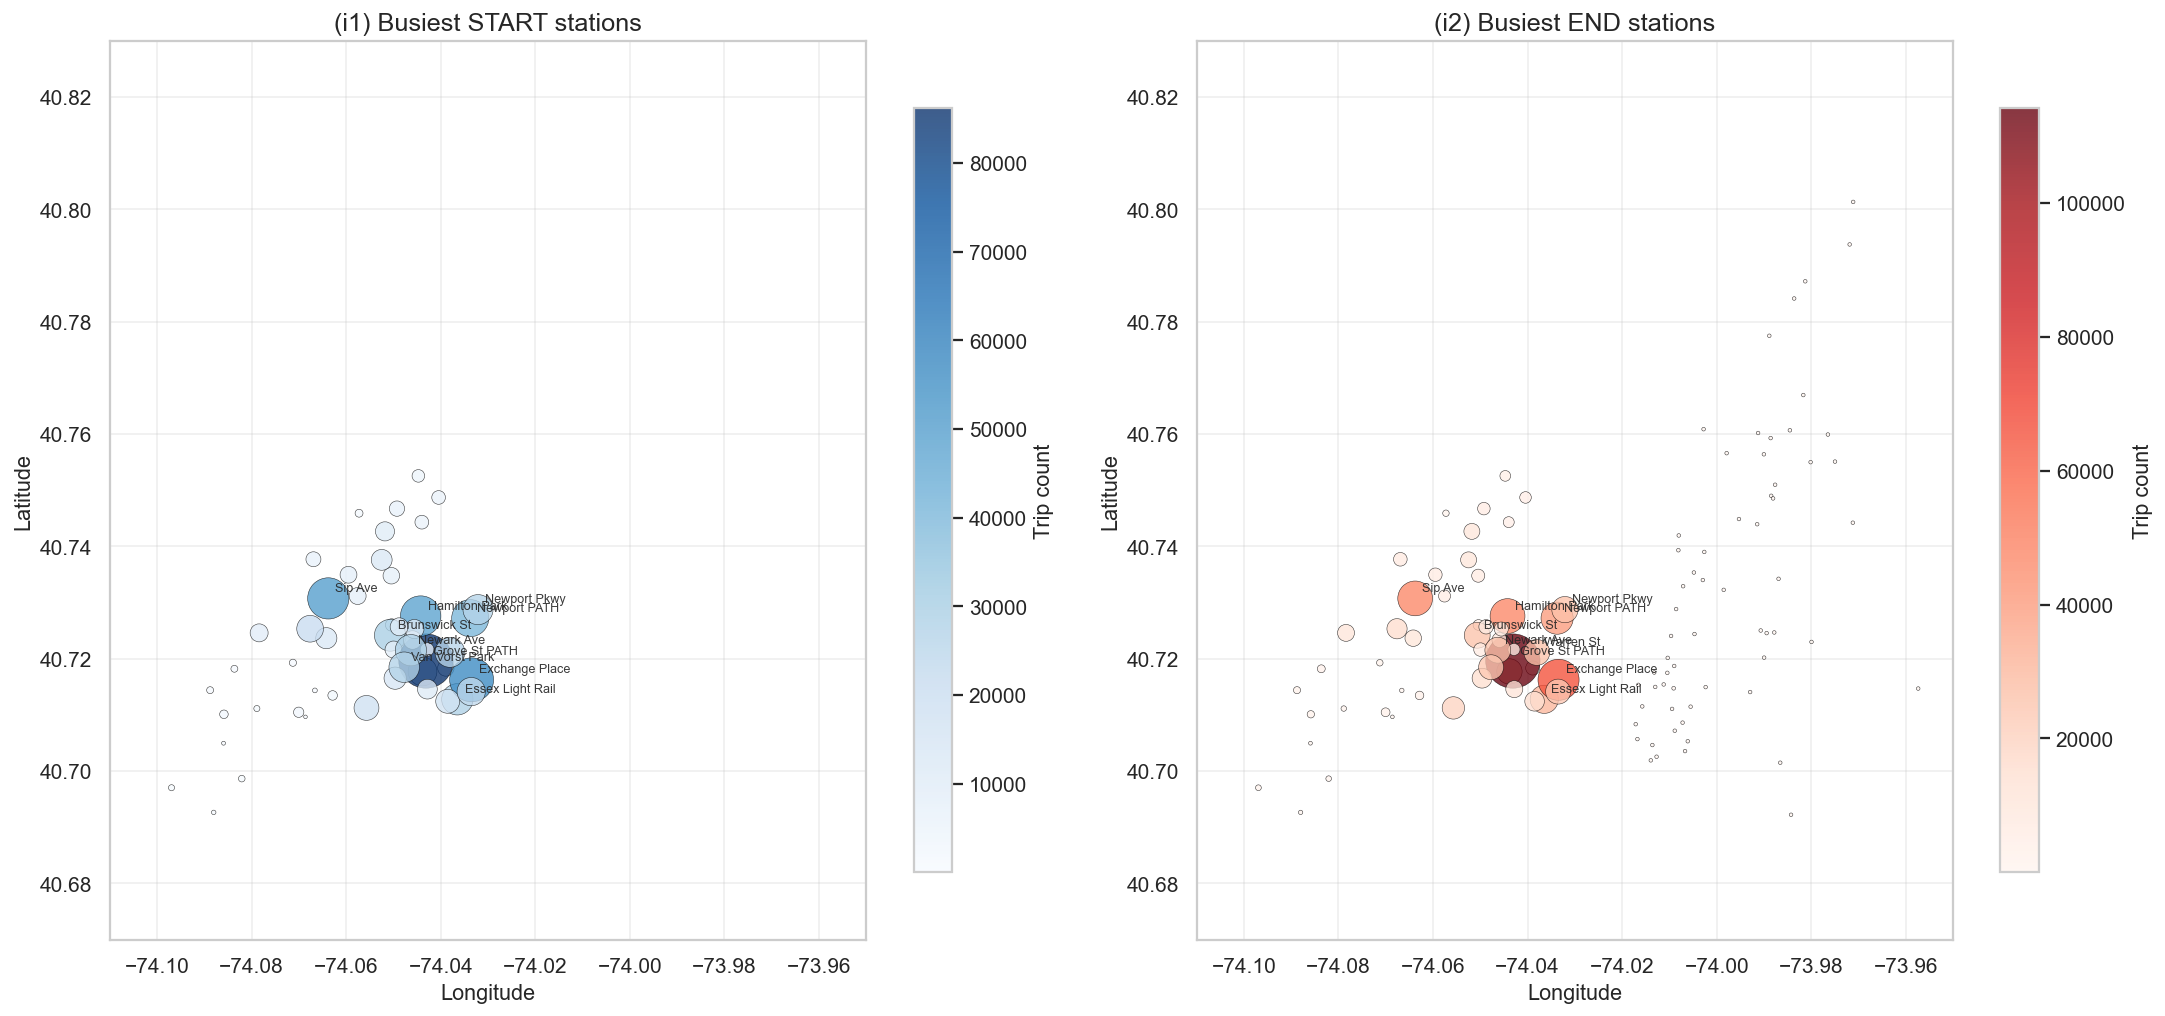

In [22]:
start_v = df.groupby(['Start Station Name','Start Station Latitude','Start Station Longitude']).size().reset_index(name='Starts')
end_v   = df.groupby(['End Station Name','End Station Latitude','End Station Longitude']).size().reset_index(name='Ends')

# Filter out invalid coordinates (0,0 entries)
start_v = start_v[(start_v['Start Station Latitude'] > 40) & (start_v['Start Station Longitude'] < -70)]
end_v   = end_v[(end_v['End Station Latitude'] > 40) & (end_v['End Station Longitude'] < -70)]

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
for ax, data, val_col, lat_col, lon_col, title, cmap in [
    (axes[0], start_v, 'Starts', 'Start Station Latitude', 'Start Station Longitude', '(i1) Busiest START stations', 'Blues'),
    (axes[1], end_v,   'Ends',   'End Station Latitude',   'End Station Longitude',   '(i2) Busiest END stations',   'Reds'),
]:
    sc = ax.scatter(data[lon_col], data[lat_col],
                    s=4 + data[val_col]/data[val_col].max()*900,
                    c=data[val_col], cmap=cmap, alpha=0.78,
                    edgecolors='black', linewidths=0.3)
    top10 = data.nlargest(10, val_col)
    for _, r in top10.iterrows():
        ax.annotate(r['End Station Name' if val_col=='Ends' else 'Start Station Name'][:20],
                    (r[lon_col], r[lat_col]),
                    fontsize=7, alpha=0.9, xytext=(4,4), textcoords='offset points')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Trip count', shrink=0.85)

axes[0].set_xlim(-74.11, -73.95)
axes[0].set_ylim(40.67, 40.83)
axes[1].set_xlim(-74.11, -73.95)
axes[1].set_ylim(40.67, 40.83)
plt.tight_layout(); plt.savefig('viz_i_busiest_stations_map.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (i)

**a) Data Types:**
- Latitude, Longitude — Quantitative (continuous, geographic)
- Station Name — Nominal
- Trip Count — Quantitative (discrete)

**b) Marks and Channels:**
- **Marks:** Point marks (proportional symbols) on a geographic plane
- **Channels:** Spatial position (lat/lon), point area (trip count), colour saturation (sequential, reinforces count), text labels (top 10 stations)

**c) Best Practices Applied:**
- Two side-by-side maps separating *start* (blue) from *end* (red) traffic so the asymmetry is visible
- Equal aspect ratio so geographic distances are not distorted
- Both **size and colour** encode count — redundant encoding aids accessibility for colour-impaired readers
- Only the top 10 stations are labelled per map
- Sequential colourmap because trip count is unidirectional

**d) Justification:**
A proportional-symbol map is the standard choropleth alternative when the geographic units are points (stations) rather than polygons (boroughs). Comparing the two maps confirms that the busiest start stations and busiest end stations are essentially the same set — i.e.\ traffic is broadly bidirectional — with Grove St PATH and Exchange Place dominating both sides.

---
## (j) How do neighbourhood shapes morph when scaled by total bike usage? (Dorling-style cartogram)

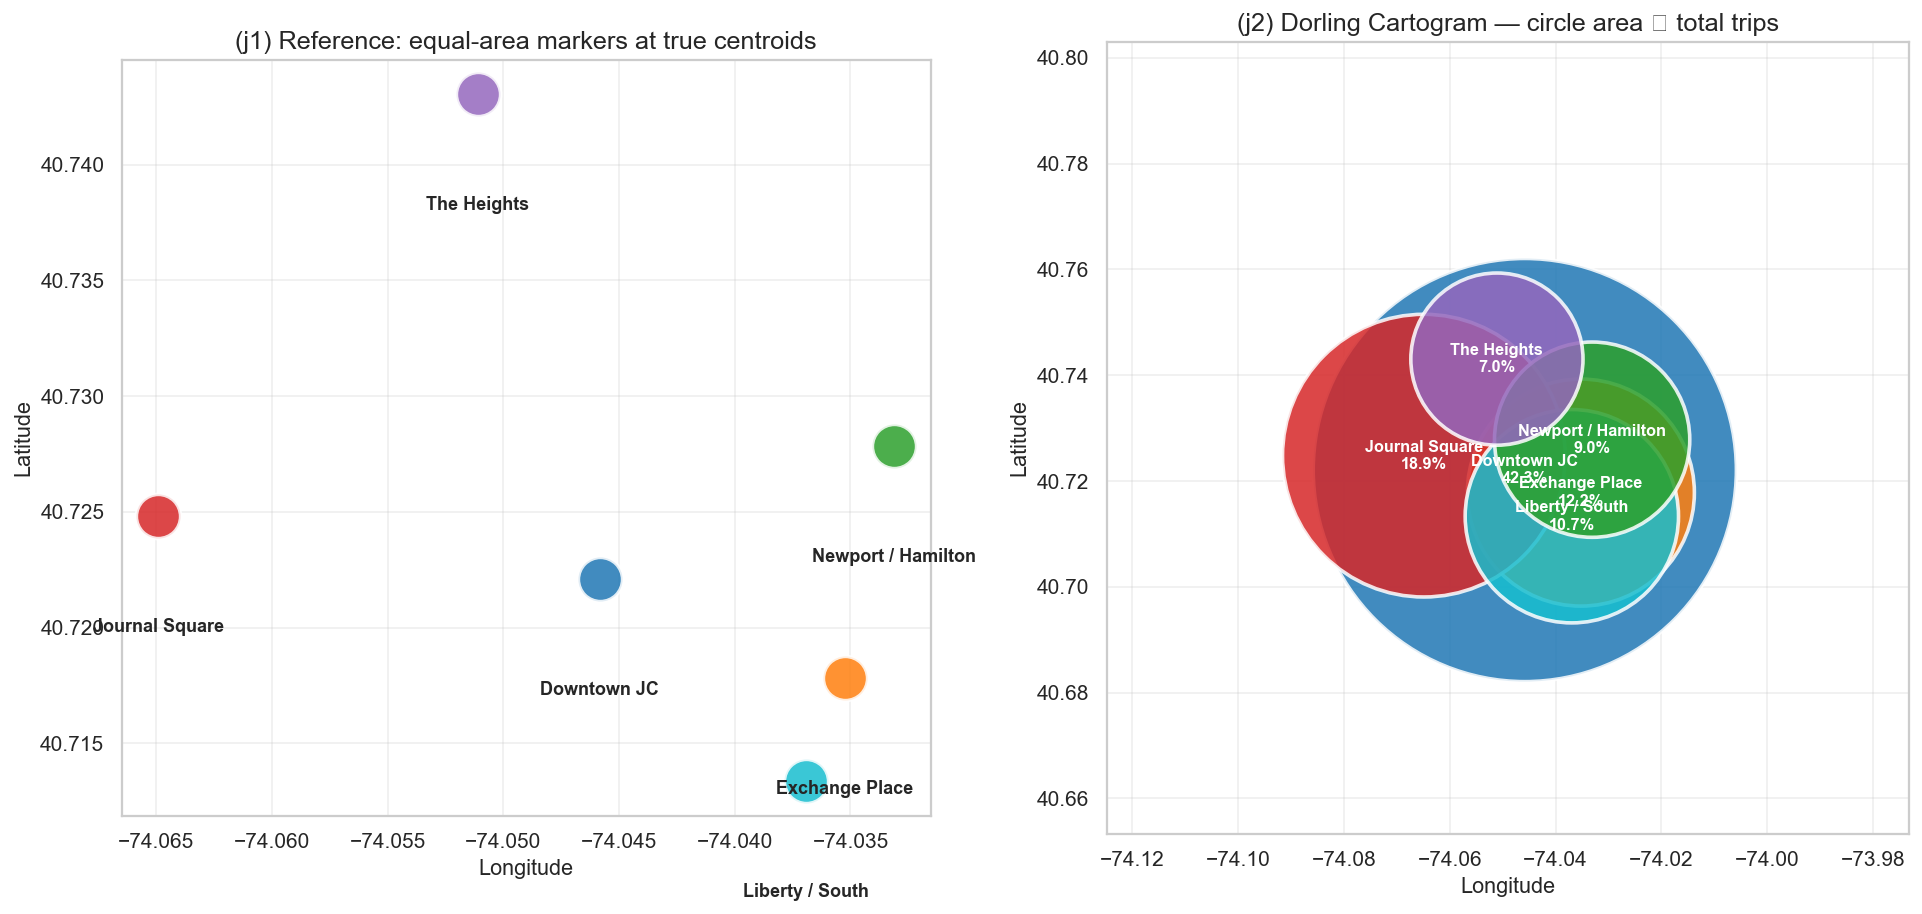

In [23]:
# Real centroids approximated from station coords; sizes proportional to trip count
borough_geo = (df.dropna(subset=['Start Station Latitude','Start Station Longitude'])
                 .groupby('Start Borough')
                 .agg(lat=('Start Station Latitude','mean'),
                      lon=('Start Station Longitude','mean'),
                      Trips=('Trip Duration','count')).reset_index())
borough_geo = borough_geo[borough_geo['Start Borough'] != 'Other'].copy()
borough_geo['Frac'] = borough_geo['Trips'] / borough_geo['Trips'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# Left: true geographic positions, equal-size markers (reference map)
ax = axes[0]
for _, r in borough_geo.iterrows():
    ax.scatter(r['lon'], r['lat'], s=600, color=BOROUGH_COLORS.get(r['Start Borough'],'#888'),
               alpha=0.85, edgecolors='white', linewidths=2)
    ax.text(r['lon'], r['lat']-0.005, r['Start Borough'], ha='center', fontsize=10, fontweight='bold')
ax.set_title('(j1) Reference: equal-area markers at true centroids')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.grid(True, alpha=0.3); ax.set_aspect('equal')

# Right: Dorling cartogram — circle area proportional to trip volume
ax = axes[1]
max_r = 0.04  # in degrees, controls visual scale
for _, r in borough_geo.iterrows():
    radius = max_r * np.sqrt(r['Frac'] / borough_geo['Frac'].max())
    circ = Circle((r['lon'], r['lat']), radius,
                  facecolor=BOROUGH_COLORS.get(r['Start Borough'],'#888'),
                  alpha=0.85, edgecolor='white', linewidth=2)
    ax.add_patch(circ)
    ax.text(r['lon'], r['lat'], f"{r['Start Borough']}\n{r['Frac']*100:.1f}%",
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')
pad = max_r * 1.5
ax.set_xlim(borough_geo['lon'].min()-pad, borough_geo['lon'].max()+pad)
ax.set_ylim(borough_geo['lat'].min()-pad, borough_geo['lat'].max()+pad)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('(j2) Dorling Cartogram — circle area ∝ total trips')
plt.tight_layout(); plt.savefig('viz_j_cartogram.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (j)

**a) Data Types:**
- Borough — Nominal
- Borough centroid (lat / lon) — Quantitative (continuous geographic)
- Total Trips per Borough — Quantitative (discrete)

**b) Marks and Channels:**
- **Marks:** Filled circles, one per neighbourhood
- **Channels:** Spatial position (centroid lat/lon), area (trip volume — Dorling encoding), colour hue (neighbourhood identity), text label (name + percentage)

**c) Best Practices Applied:**
- A **reference map** with equal-area markers is shown side-by-side so the cartogram distortion is immediately interpretable
- **Area** (not radius) is mapped to trip volume — a perceptually correct ratio encoding
- Equal aspect ratio so circles are not stretched into ellipses
- Each circle carries both name and percentage; no separate legend needed
- Borough colour palette consistent with all other charts in the report

**d) Justification:**
A Dorling cartogram is the simplest non-contiguous cartogram and is appropriate when polygon geometry is unavailable or not the focus. It deliberately distorts size to reveal *thematic dominance*: the Downtown JC circle visually swamps the others, communicating instantly that this bikeshare is centred on the Downtown / PATH corridor, with Exchange Place and Newport / Hamilton as secondary hubs.

---
## (k) What does neighbourhood-level trip activity look like in a simplified schematic view?

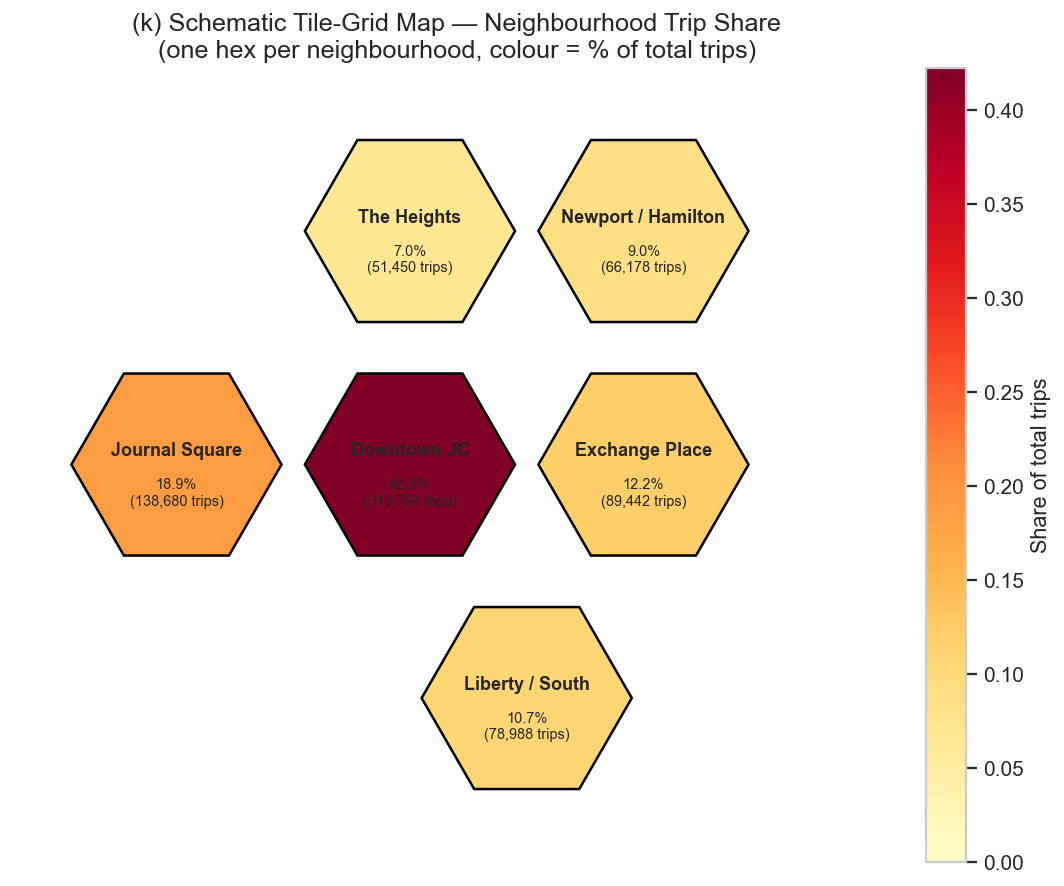

In [24]:
# Tile grid map — each neighbourhood = one hex tile; colour = trip share.
# Layout roughly preserves real adjacency.
tile_layout = {
    'The Heights':         (-0.5,  1.0),
    'Journal Square':      (-1.5,  0.0),
    'Newport / Hamilton':  ( 0.5,  1.0),
    'Downtown JC':         (-0.5,  0.0),
    'Exchange Place':      ( 0.5,  0.0),
    'Liberty / South':     ( 0.0, -1.0),
}
tot = df.groupby('Start Borough').size()
frac = (tot / tot.sum()).to_dict()

fig, ax = plt.subplots(figsize=(11, 7))
size = 0.45
from matplotlib import cm
norm = plt.Normalize(vmin=0, vmax=max(frac.get(b, 0) for b in tile_layout))
cmap = cm.get_cmap('YlOrRd')
for b, (cx, cy) in tile_layout.items():
    f = frac.get(b, 0)
    hex_patch = RegularPolygon((cx, cy), numVertices=6, radius=size,
                               orientation=np.radians(30),
                               facecolor=cmap(norm(f)),
                               edgecolor='black', linewidth=1.4)
    ax.add_patch(hex_patch)
    n_trips = int(tot.get(b, 0))
    ax.text(cx, cy + 0.06, b, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(cx, cy - 0.12, f'{f*100:.1f}%\n({n_trips:,} trips)', ha='center', va='center', fontsize=8)
ax.set_xlim(-2.2, 1.6); ax.set_ylim(-1.7, 1.7); ax.set_aspect('equal'); ax.axis('off')
ax.set_title('(k) Schematic Tile-Grid Map — Neighbourhood Trip Share\n(one hex per neighbourhood, colour = % of total trips)')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02); cbar.set_label('Share of total trips')
plt.tight_layout(); plt.savefig('viz_k_schematic_tilemap.png', dpi=200, bbox_inches='tight'); plt.show()


### Task 2 — Analysis for (k)

**a) Data Types:**
- Borough — Nominal
- Trip Share (proportion of total) — Quantitative (continuous, 0–1)

**b) Marks and Channels:**
- **Marks:** Regular hexagon tiles (one per neighbourhood)
- **Channels:** Tile colour saturation (sequential, trip share), tile relative position (preserves rough geographic adjacency), text annotation (name + share + count)

**c) Best Practices Applied:**
- Hexagons sized **identically** so the eye never compares area incorrectly — only colour encodes the metric
- Tiles arranged so adjacency roughly matches real geography (The Heights to the north, Journal Square to the west, Newport / Hamilton on the NE waterfront, Exchange Place on the E waterfront, Liberty / South to the south)
- Sequential colourmap (`YlOrRd`) appropriate for a single unidirectional quantity
- Both percentage *and* raw count appear inside every tile
- Borders and the colour-bar legend are explicit

**d) Justification:**
A schematic tile-grid map sacrifices geographic accuracy for **comparability**: every neighbourhood gets equal visual prominence, so smaller-but-interesting regions (e.g.\ Liberty / South or The Heights) cannot be visually overwhelmed by the dominant Downtown JC core. This complements the Dorling cartogram in (j) — together they offer a full ‘distort area’ vs ‘equal area’ pair, both encoding the same quantitative variable.

---
## (l) How do trip origins and destinations distribute spatially across the city over time (peak vs off-peak)?

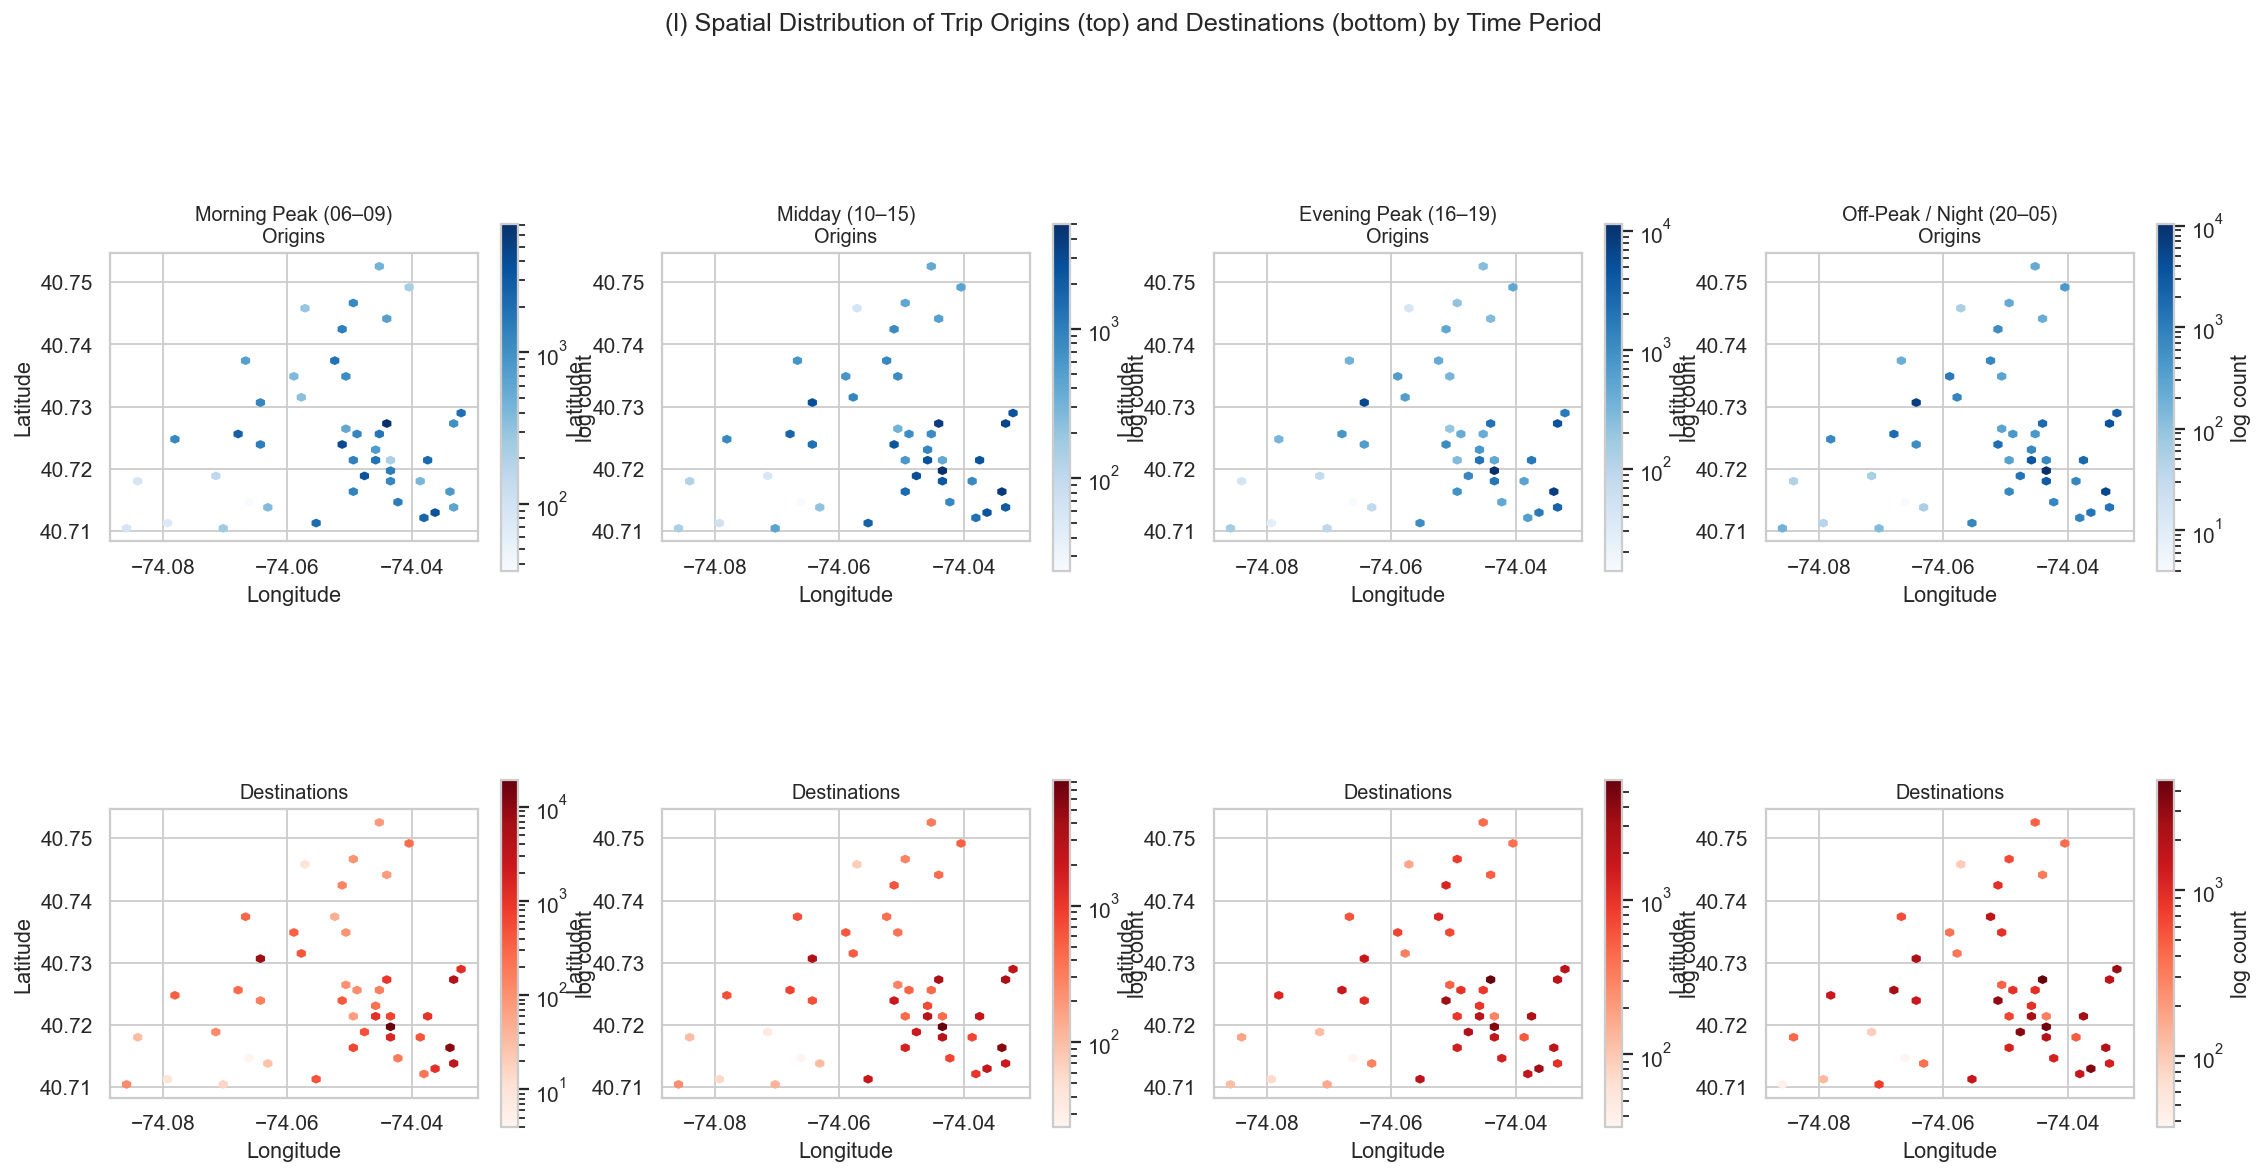

In [25]:
periods = ['Morning Peak (06–09)', 'Midday (10–15)', 'Evening Peak (16–19)', 'Off-Peak / Night (20–05)']
fig, axes = plt.subplots(2, 4, figsize=(21, 10),
                          gridspec_kw={'hspace':0.25, 'wspace':0.20})
lon_min, lon_max = df['Start Station Longitude'].quantile([0.005, 0.995])
lat_min, lat_max = df['Start Station Latitude'].quantile([0.005, 0.995])
for col, p in enumerate(periods):
    sub = df[df['TimePeriod'] == p].sample(min(60_000, (df['TimePeriod']==p).sum()), random_state=42)
    # Origins (top row)
    h1 = axes[0, col].hexbin(sub['Start Station Longitude'], sub['Start Station Latitude'],
                              gridsize=45, cmap='Blues', mincnt=1, bins='log',
                              extent=(lon_min, lon_max, lat_min, lat_max))
    axes[0, col].set_title(f'{p}\nOrigins', fontsize=11)
    plt.colorbar(h1, ax=axes[0, col], shrink=0.78, label='log count')
    # Destinations (bottom row)
    h2 = axes[1, col].hexbin(sub['End Station Longitude'], sub['End Station Latitude'],
                              gridsize=45, cmap='Reds', mincnt=1, bins='log',
                              extent=(lon_min, lon_max, lat_min, lat_max))
    axes[1, col].set_title('Destinations', fontsize=11)
    plt.colorbar(h2, ax=axes[1, col], shrink=0.78, label='log count')
for ax in axes.flat:
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_aspect('equal')
fig.suptitle('(l) Spatial Distribution of Trip Origins (top) and Destinations (bottom) by Time Period',
             fontsize=14, y=1.005)
plt.tight_layout(); plt.savefig('viz_l_spatial_time_periods.png', dpi=200, bbox_inches='tight'); plt.show()

### Task 2 — Analysis for (l)

**a) Data Types:**
- Latitude, Longitude — Quantitative (continuous, geographic)
- Time Period — Ordinal (Morning Peak / Midday / Evening Peak / Off-Peak)
- Origin/Destination role — Nominal (binary)
- Trip Count per Hex Cell — Quantitative (discrete, log-scaled for display)

**b) Marks and Channels:**
- **Marks:** Hexagonal bin tiles (density grid)
- **Channels:** Spatial position (lat/lon), colour saturation (log trip count), small-multiple position (time period × origin/destination role), colour hue (blue = origins, red = destinations)

**c) Best Practices Applied:**
- A **2 × 4 grid of small multiples** (time period × role) lets the reader compare 8 spatial slices at a glance
- **Identical lat/lon extents** across all 8 panels so density patterns are directly comparable
- **Logarithmic bin colour** so a few super-busy hexes do not flatten the rest of the map
- Sample of up to 60 000 trips per period keeps rendering fast without losing the spatial pattern
- Two distinct sequential colourmaps (Blues / Reds) reinforce the origin–destination role

**d) Justification:**
Hexbin density maps are the recommended technique when many thousand point coordinates would overplot. Faceting by time period reveals the **diffusion–concentration** behaviour of the system: morning-peak origins are tightly concentrated around residential areas while destinations spread toward PATH hubs, and this pattern reverses in the evening peak. Off-peak/night activity is thin and mostly concentrated on a few stations near nightlife districts.

---
## Summary

All **12 visualizations** (a–l) covering the network and spatial dimensions of the Citi Bike dataset have been created .

Each visualization is paired with a Task 2 analysis covering:
- **(a)** data types depicted
- **(b)** marks and channels
- **(c)** best practices applied
- **(d)** justification of the visualization choice